In [ ]:
import cv2import numpy as npimport shutilimport timefrom pathlib import Pathfrom concurrent.futures import ThreadPoolExecutor, as_completedfrom tqdm import tqdmDRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")LOCAL_FINAL = Path("/content/training_final")WORKERS     = 64# ── ADIM 1: Drive → Locale ────────────────────────────────────────────────────print("="*55)print("  ADIM 1: Drive → Locale kopyalama")print("="*55)all_files = []for f in DRIVE_OUT.rglob("*.jpg"):    rel = f.relative_to(DRIVE_OUT)    dst = LOCAL_FINAL / rel    all_files.append((f, dst))print(f"Toplam dosya: {len(all_files)}")def copy_file(args):    src, dst = args    dst.parent.mkdir(parents=True, exist_ok=True)    if not dst.exists():        shutil.copy2(str(src), str(dst))t0 = time.time()with ThreadPoolExecutor(max_workers=WORKERS) as ex:    list(tqdm(ex.map(copy_file, all_files),              total=len(all_files), desc="Kopyalanıyor"))local_count = len(list(LOCAL_FINAL.rglob("*.jpg")))print(f"✓ {time.time()-t0:.0f}sn  Drive:{len(all_files)}  Locale:{local_count}  "      f"{'✓' if local_count==len(all_files) else '✗ EKSİK'}")print("\n── Yapı kontrolü ───────────────────────────────────────")CLASSES = ["normal","trespassing","loitering","object_abandonment"]for split in ["train","test"]:    for cls in CLASSES:        cls_dir = LOCAL_FINAL / split / cls        if not cls_dir.exists(): continue        clips = len(list(cls_dir.rglob("frame_001.jpg")))        print(f"  {split}/{cls:<22} {clips} klip")

  ADIM 1: Drive → Locale kopyalama
Toplam dosya: 23687


Kopyalanıyor: 100%|██████████| 23687/23687 [02:15<00:00, 174.28it/s]


✓ 137sn  Drive:23687  Locale:23687  ✓

── Yapı kontrolü ───────────────────────────────────────
  train/normal                 273 klip
  train/trespassing            321 klip
  train/loitering              273 klip
  train/object_abandonment     285 klip
  test/normal                 88 klip
  test/trespassing            95 klip
  test/loitering              81 klip
  test/object_abandonment     81 klip


In [ ]:
import cv2import numpy as npimport timefrom pathlib import Pathfrom concurrent.futures import ThreadPoolExecutor, as_completedfrom tqdm import tqdmLOCAL_FINAL = Path("/content/training_final")NPY_DIR     = LOCAL_FINAL / "npy_cache"NPY_DIR.mkdir(exist_ok=True)CLASSES  = ["normal","trespassing","loitering","object_abandonment"]IMG_SIZE = 112CLIP_LEN = 16WORKERS  = 32MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)def preprocess_clip(clip_dir):    frames_paths = sorted(clip_dir.glob("*.jpg"))    if len(frames_paths) != CLIP_LEN: return None    frames = []    for fp in frames_paths:        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)        if img is None: return None        img   = cv2.resize(img, (IMG_SIZE,IMG_SIZE),                           interpolation=cv2.INTER_LINEAR)        img_f = img.astype(np.float32) / 255.0        img_3 = np.stack([img_f]*3, axis=0)        for c in range(3):            img_3[c] = (img_3[c] - MEAN[c]) / STD[c]        frames.append(img_3)    return np.stack(frames, axis=0).astype(np.float32)print("Klip listesi hazırlanıyor...")all_jobs = []for split in ["train","test"]:    for cls in CLASSES:        cls_dir = LOCAL_FINAL / split / cls        if not cls_dir.exists(): continue        for day_dir in sorted(cls_dir.iterdir()):            if not day_dir.is_dir(): continue            for clip_dir in sorted(day_dir.iterdir()):                if not clip_dir.is_dir(): continue                if len(list(clip_dir.glob("*.jpg"))) == CLIP_LEN:                    all_jobs.append((split, cls,                                     day_dir.name,                                     clip_dir.name,                                     clip_dir))print(f"Toplam klip: {len(all_jobs)}")def process_and_save(job):    split, cls, day, clip_name, clip_dir = job    out_dir  = NPY_DIR / split / cls / day    out_dir.mkdir(parents=True, exist_ok=True)    out_path = out_dir / f"{clip_name}.npy"    if out_path.exists(): return "skip"    arr = preprocess_clip(clip_dir)    if arr is None: return "error"    np.save(str(out_path), arr)    return "ok"print(f"Preprocess ({WORKERS} worker)...")t0  = time.time()res = {"ok":0,"skip":0,"error":0}with ThreadPoolExecutor(max_workers=WORKERS) as ex:    futures = {ex.submit(process_and_save,j):j for j in all_jobs}    for f in tqdm(as_completed(futures), total=len(all_jobs)):        res[f.result()] += 1print(f"✓ {time.time()-t0:.0f}sn  {res}")print("\n── NPY Cache Özet ──────────────────────────────────────")total_size = 0for split in ["train","test"]:    for cls in CLASSES:        cls_dir = NPY_DIR/split/cls        if not cls_dir.exists(): continue        npys = list(cls_dir.rglob("*.npy"))        size = sum(f.stat().st_size for f in npys)        total_size += size        print(f"  {split}/{cls:<22} {len(npys):>5} klip  {size/1e6:>8.1f}MB")print(f"\n  Toplam: {total_size/1e9:.2f} GB")sample = list((NPY_DIR/"train"/"normal").rglob("*.npy"))[0]arr    = np.load(str(sample))print(f"  Shape: {arr.shape}  dtype:{arr.dtype}")print(f"  Min:{arr.min():.3f}  Max:{arr.max():.3f}")

Klip listesi hazırlanıyor...
Toplam klip: 1466
Preprocess (32 worker)...


100%|██████████| 1466/1466 [00:10<00:00, 135.80it/s]


✓ 11sn  {'ok': 1465, 'skip': 0, 'error': 1}

── NPY Cache Özet ──────────────────────────────────────
  train/normal                   273 klip     657.5MB
  train/trespassing              290 klip     698.5MB
  train/loitering                272 klip     655.1MB
  train/object_abandonment       285 klip     686.4MB
  test/normal                    88 klip     212.0MB
  test/trespassing               95 klip     228.8MB
  test/loitering                 81 klip     195.1MB
  test/object_abandonment        81 klip     195.1MB

  Toplam: 3.53 GB
  Shape: (16, 3, 112, 112)  dtype:float32
  Min:-2.118  Max:2.640


In [ ]:
from pathlib import PathDRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")LOCAL_FINAL = Path("/content/training_final")print("── Drive vs Locale Karşılaştırma ───────────────────────")for split in ["train","test"]:    for cls in ["normal","trespassing","loitering","object_abandonment"]:        drive_clips = len(list((DRIVE_OUT/split/cls).rglob("frame_001.jpg"))) \                      if (DRIVE_OUT/split/cls).exists() else 0        local_clips = len(list((LOCAL_FINAL/split/cls).rglob("frame_001.jpg"))) \                      if (LOCAL_FINAL/split/cls).exists() else 0        flag = "✓" if drive_clips==local_clips else "✗ FARK!"        print(f"  {split}/{cls:<22} Drive:{drive_clips:>4}  "              f"Local:{local_clips:>4}  {flag}")

── Drive vs Locale Karşılaştırma ───────────────────────
  train/normal                 Drive: 273  Local: 273  ✓
  train/trespassing            Drive: 321  Local: 321  ✓
  train/loitering              Drive: 273  Local: 273  ✓
  train/object_abandonment     Drive: 285  Local: 285  ✓
  test/normal                 Drive:  88  Local:  88  ✓
  test/trespassing            Drive:  95  Local:  95  ✓
  test/loitering              Drive:  81  Local:  81  ✓
  test/object_abandonment     Drive:  81  Local:  81  ✓


── CNN8 Hiperparametreler ───────────────────────────────
  Maskeleme    : YOK
  Batch        : 32
  LR_FC/FT     : 0.001/0.0001
  Dropout      : 0.4
  LabelSmooth  : 0.1
  WeightDecay  : 0.0002
  Val ratio    : 0.2
  Epochs       : 50
  Patience     : 10
[train] 1120 klip
[test] 345 klip

── Val Split ───────────────────────────────────────────
  normal                 tr: 249(101gün)  val:  24( 24gün)
  trespassing            tr: 263(110gün)  val:  27( 27gün)
  loitering              tr: 243( 33gün)  val:  29(  7gün)
  object_abandonment     tr: 268( 41gün)  val:  17(  9gün)

Train:1023  Val:97  Test:345

  Sınıf                      Train    Val   Test
  ------------------------------------------
  normal                       249     24     88
  trespassing                  263     27     95
  loitering                    243     29     81
  object_abandonment           268     17     81

Train-Val gün çakışması: VAR! {'20200711', '20210222', '20200813', '20200606', '20210408', '20

100%|██████████| 127M/127M [00:00<00:00, 202MB/s]



  CNN8 EĞİTİM — 50 epoch
Epoch  1/50 [FC] tr:1.3635 | val_loss:1.3348 val_acc:0.361 val_f1:0.303 | lr:1.0e-03 | 8sn
  ✓ CNN8 best F1=0.303
Epoch  2/50 [FC] tr:1.1513 | val_loss:1.2022 val_acc:0.474 val_f1:0.420 | lr:1.0e-03 | 4sn
  ✓ CNN8 best F1=0.420
Epoch  3/50 [FC] tr:1.0480 | val_loss:1.1165 val_acc:0.649 val_f1:0.605 | lr:1.0e-03 | 4sn
  ✓ CNN8 best F1=0.605
Epoch  4/50 [FC] tr:0.9961 | val_loss:1.1220 val_acc:0.639 val_f1:0.568 | lr:1.0e-03 | 4sn
Epoch  5/50 [FC] tr:0.9475 | val_loss:1.0432 val_acc:0.670 val_f1:0.625 | lr:1.0e-03 | 4sn
  ✓ CNN8 best F1=0.625

→ Backbone açılıyor
Epoch  6/50 [FT] tr:0.5875 | val_loss:0.7198 val_acc:0.835 val_f1:0.815 | lr:1.0e-04 | 15sn
  ✓ CNN8 best F1=0.815
Epoch  7/50 [FT] tr:0.4238 | val_loss:0.6234 val_acc:0.876 val_f1:0.863 | lr:1.0e-04 | 11sn
  ✓ CNN8 best F1=0.863
Epoch  8/50 [FT] tr:0.3989 | val_loss:0.6259 val_acc:0.876 val_f1:0.862 | lr:9.9e-05 | 11sn
Epoch  9/50 [FT] tr:0.3880 | val_loss:0.6102 val_acc:0.887 val_f1:0.879 | lr:9.8e-05

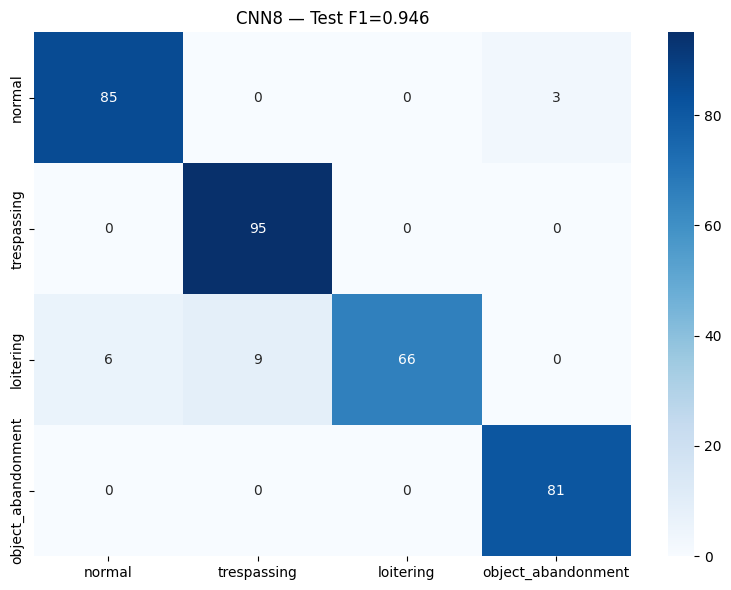

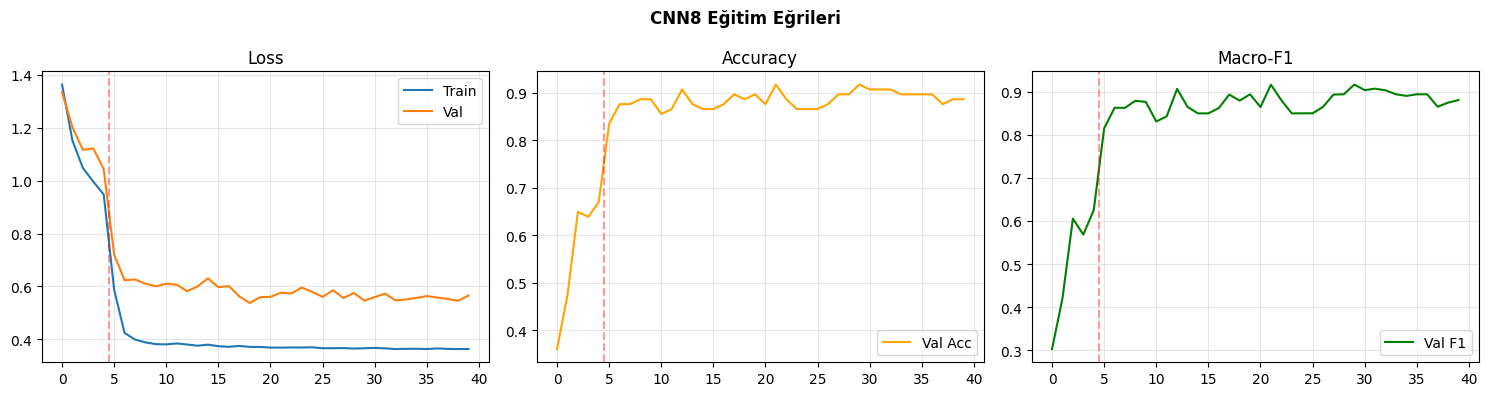


✓ CNN8: /content/cnn8_checkpoints / /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn8_model


In [ ]:
import torchimport torch.nn as nnimport torch.optim as optimfrom torchvision.models.video import r3d_18, R3D_18_Weightsfrom torch.amp import GradScaler, autocastfrom torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subsetfrom collections import defaultdictfrom sklearn.metrics import classification_report, confusion_matrix, f1_scoreimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsimport time, shutil, randomfrom pathlib import PathCLASSES   = ["normal","trespassing","loitering","object_abandonment"]N_CLASSES = 4DEVICE    = torch.device("cuda")LOCAL_FINAL = Path("/content/training_final")NPY_DIR     = LOCAL_FINAL / "npy_cache"SAVE_LOCAL = Path("/content/cnn8_checkpoints")SAVE_LOCAL.mkdir(exist_ok=True)SAVE_DRIVE = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn8_model")SAVE_DRIVE.mkdir(parents=True, exist_ok=True)torch.backends.cudnn.benchmark = Truerandom.seed(42)np.random.seed(42)EPOCHS_FROZEN   = 5EPOCHS_FINETUNE = 45EPOCHS_TOTAL    = EPOCHS_FROZEN + EPOCHS_FINETUNEPATIENCE        = 10BATCH_SIZE      = 32LR_FC           = 1e-3LR_FT           = 1e-4WEIGHT_DECAY    = 2e-4DROPOUT         = 0.4LABEL_SMOOTH    = 0.1VAL_RATIO       = 0.20def is_winter(day): return 202101 <= int(day[:6]) <= 202103print("── CNN8 Hiperparametreler ───────────────────────────────")print(f"  Maskeleme    : YOK")print(f"  Batch        : {BATCH_SIZE}")print(f"  LR_FC/FT     : {LR_FC}/{LR_FT}")print(f"  Dropout      : {DROPOUT}")print(f"  LabelSmooth  : {LABEL_SMOOTH}")print(f"  WeightDecay  : {WEIGHT_DECAY}")print(f"  Val ratio    : {VAL_RATIO}")print(f"  Epochs       : {EPOCHS_TOTAL}")print(f"  Patience     : {PATIENCE}")# ── Dataset ───────────────────────────────────────────────────────────────────class ClipDataset(Dataset):    def __init__(self, split, augment=False):        self.samples = []        self.augment = augment        for cls in CLASSES:            cls_dir = NPY_DIR / split / cls            if not cls_dir.exists(): continue            for npy in sorted(cls_dir.rglob("*.npy")):                self.samples.append((npy, CLASSES.index(cls)))        random.shuffle(self.samples)        print(f"[{split}] {len(self.samples)} klip")    def __len__(self): return len(self.samples)    def __getitem__(self, idx):        npy_path, label = self.samples[idx]        clip = np.load(str(npy_path))        if self.augment and random.random() > 0.5:            clip = clip[::-1].copy()        return torch.from_numpy(clip).permute(1,0,2,3), labeltrain_ds8 = ClipDataset("train", augment=True)test_ds8  = ClipDataset("test",  augment=False)# ── Mevsim+Ay dengeli stratified val split ────────────────────────────────────def stratified_val_split(samples, val_ratio=0.20):    cls_day = defaultdict(lambda: defaultdict(list))    for i,(npy_path,label) in enumerate(samples):        cls_day[label][npy_path.parent.name].append(i)    train_idx, val_idx = [], []    print("\n── Val Split ───────────────────────────────────────────")    for label in range(N_CLASSES):        days_by_size = sorted(            cls_day[label].keys(),            key=lambda d: len(cls_day[label][d])        )        winter_days = [d for d in days_by_size if is_winter(d)]        summer_days = [d for d in days_by_size if not is_winter(d)]        n_val_w = max(1, int(len(winter_days)*val_ratio))        n_val_s = max(1, int(len(summer_days)*val_ratio))        val_days = set(winter_days[:n_val_w]) | set(summer_days[:n_val_s])        tr_days  = set(days_by_size) - val_days        for day,idxs in cls_day[label].items():            if day in val_days: val_idx.extend(idxs)            else:               train_idx.extend(idxs)        vc = sum(len(cls_day[label][d]) for d in val_days)        tc = sum(len(cls_day[label][d]) for d in tr_days)        print(f"  {CLASSES[label]:<22} tr:{tc:>4}({len(tr_days):>3}gün)  "              f"val:{vc:>4}({len(val_days):>3}gün)")    return train_idx, val_idxtrain_indices8, val_indices8 = stratified_val_split(    train_ds8.samples, VAL_RATIO)train_sub8 = Subset(train_ds8, train_indices8)val_sub8   = Subset(train_ds8, val_indices8)val_cls = defaultdict(int)tr_cls  = defaultdict(int)for i in val_indices8:    val_cls[CLASSES[train_ds8.samples[i][1]]] += 1for i in train_indices8:    tr_cls[CLASSES[train_ds8.samples[i][1]]] += 1print(f"\nTrain:{len(train_sub8)}  Val:{len(val_sub8)}  Test:{len(test_ds8)}")print(f"\n  {'Sınıf':<25} {'Train':>6} {'Val':>6} {'Test':>6}")print("  "+"-"*42)for c in CLASSES:    te = sum(1 for _,l in test_ds8.samples if CLASSES[l]==c)    print(f"  {c:<25} {tr_cls[c]:>6} {val_cls[c]:>6} {te:>6}")tr_day_set  = {train_ds8.samples[i][0].parent.name for i in train_indices8}val_day_set = {train_ds8.samples[i][0].parent.name for i in val_indices8}ov = tr_day_set & val_day_setprint(f"\nTrain-Val gün çakışması: {'YOK ✓' if not ov else f'VAR! {ov}'}")# ── Weighted sampler ──────────────────────────────────────────────────────────cnt = defaultdict(int)for i in train_indices8:    cnt[train_ds8.samples[i][1]] += 1total_tr = len(train_indices8)w_sample = [total_tr/(N_CLASSES*cnt[train_ds8.samples[i][1]])            for i in train_indices8]sampler8 = WeightedRandomSampler(w_sample, len(w_sample), replacement=True)weights  = torch.tensor([total_tr/(N_CLASSES*cnt[i])                         for i in range(N_CLASSES)],                        dtype=torch.float32).to(DEVICE)print(f"\nClass weights: {weights.cpu().numpy().round(3)}")# ── DataLoaders ───────────────────────────────────────────────────────────────kw = dict(num_workers=2, pin_memory=True,          persistent_workers=True, prefetch_factor=2)train_loader8 = DataLoader(train_sub8, batch_size=BATCH_SIZE,                           sampler=sampler8, **kw)val_loader8   = DataLoader(val_sub8,   batch_size=BATCH_SIZE,                           shuffle=False, **kw)test_loader8  = DataLoader(test_ds8,   batch_size=BATCH_SIZE,                           shuffle=False, **kw)# ── Model ─────────────────────────────────────────────────────────────────────model8 = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)model8.fc = nn.Sequential(    nn.Dropout(DROPOUT),    nn.Linear(model8.fc.in_features, N_CLASSES))model8     = model8.to(DEVICE)criterion8 = nn.CrossEntropyLoss(weight=weights,                                  label_smoothing=LABEL_SMOOTH)scaler8    = GradScaler('cuda')def freeze_backbone(m):    for name,p in m.named_parameters():        if "fc" not in name: p.requires_grad=Falsedef unfreeze_all(m):    for p in m.parameters(): p.requires_grad=Truefreeze_backbone(model8)optimizer8 = optim.AdamW(    filter(lambda p: p.requires_grad, model8.parameters()),    lr=LR_FC, weight_decay=WEIGHT_DECAY)# ── Train / Eval ──────────────────────────────────────────────────────────────def train_epoch(model, loader, optimizer, criterion, scaler):    model.train()    total_loss = total = 0    for clips, labels in loader:        clips  = clips.to(DEVICE, non_blocking=True)        labels = labels.to(DEVICE, non_blocking=True)        optimizer.zero_grad(set_to_none=True)        with autocast('cuda'):            loss = criterion(model(clips), labels)        scaler.scale(loss).backward()        scaler.step(optimizer)        scaler.update()        total_loss += loss.item()*labels.size(0)        total      += labels.size(0)    return total_loss/totaldef eval_epoch(model, loader, criterion):    model.eval()    total_loss=correct=total=0    all_preds, all_labels = [], []    with torch.no_grad():        for clips, labels in loader:            clips  = clips.to(DEVICE, non_blocking=True)            labels = labels.to(DEVICE, non_blocking=True)            with autocast('cuda'):                outputs = model(clips)                loss    = criterion(outputs, labels)            preds = outputs.argmax(1)            total_loss += loss.item()*labels.size(0)            correct    += (preds==labels).sum().item()            total      += labels.size(0)            all_preds.extend(preds.cpu().numpy())            all_labels.extend(labels.cpu().numpy())    f1 = f1_score(all_labels, all_preds, average='macro')    return total_loss/total, correct/total, f1, all_preds, all_labelsbest_f1=patience_cnt=0history=defaultdict(list)scheduler8=Noneprint("\n"+"="*60)print(f"  CNN8 EĞİTİM — {EPOCHS_TOTAL} epoch")print("="*60)for epoch in range(1, EPOCHS_TOTAL+1):    t0 = time.time()    if epoch == EPOCHS_FROZEN+1:        print("\n→ Backbone açılıyor")        unfreeze_all(model8)        optimizer8 = optim.AdamW(model8.parameters(),                                  lr=LR_FT,                                  weight_decay=WEIGHT_DECAY)        scheduler8 = optim.lr_scheduler.CosineAnnealingLR(            optimizer8, T_max=EPOCHS_FINETUNE, eta_min=1e-6)    tr_loss = train_epoch(model8, train_loader8,                          optimizer8, criterion8, scaler8)    val_loss, val_acc, val_f1, _,_ = eval_epoch(        model8, val_loader8, criterion8)    if scheduler8: scheduler8.step()    history["tr_loss"].append(tr_loss)    history["val_loss"].append(val_loss)    history["val_acc"].append(val_acc)    history["val_f1"].append(val_f1)    lr_now = optimizer8.param_groups[0]['lr']    phase  = "FC" if epoch<=EPOCHS_FROZEN else "FT"    print(f"Epoch {epoch:>2}/{EPOCHS_TOTAL} [{phase}] "          f"tr:{tr_loss:.4f} | "          f"val_loss:{val_loss:.4f} val_acc:{val_acc:.3f} "          f"val_f1:{val_f1:.3f} | lr:{lr_now:.1e} | "          f"{time.time()-t0:.0f}sn")    if val_f1 > best_f1:        best_f1=val_f1; patience_cnt=0        ckpt = {            "epoch":       epoch,            "model_state": model8.state_dict(),            "val_f1":      val_f1,            "val_acc":     val_acc,            "history":     dict(history),        }        torch.save(ckpt, str(SAVE_LOCAL/"best_model.pth"))        shutil.copy2(str(SAVE_LOCAL/"best_model.pth"),                     str(SAVE_DRIVE/"best_model.pth"))        print(f"  ✓ CNN8 best F1={best_f1:.3f}")    else:        patience_cnt += 1        if patience_cnt>=PATIENCE and epoch>EPOCHS_FROZEN:            print(f"\n  Early stopping")            break# ── Final test ────────────────────────────────────────────────────────────────print("\n"+"="*60)print("  CNN8 FINAL TEST")print("="*60)ckpt = torch.load(str(SAVE_LOCAL/"best_model.pth"))model8.load_state_dict(ckpt["model_state"])_, test_acc, test_f1, preds, labels = eval_epoch(    model8, test_loader8, criterion8)print(f"\nBest epoch:{ckpt['epoch']}  "      f"Test Acc:{test_acc:.3f}  Test F1:{test_f1:.3f}")print("\nClassification Report:")print(classification_report(labels, preds,                             target_names=CLASSES, digits=3))_, tr_acc, tr_f1, _,_ = eval_epoch(model8, train_loader8, criterion8)print(f"\nOverfitting kontrolü:")print(f"  Train F1 : {tr_f1:.3f}")print(f"  Test  F1 : {test_f1:.3f}")print(f"  Gap      : {tr_f1-test_f1:.3f}")# Confusion Matrixcm = confusion_matrix(labels, preds)fig, ax = plt.subplots(figsize=(8,6))sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',            xticklabels=CLASSES, yticklabels=CLASSES)ax.set_title(f"CNN8 — Test F1={test_f1:.3f}")plt.tight_layout()for dst in [SAVE_LOCAL, SAVE_DRIVE]:    plt.savefig(str(dst/"confusion_matrix.png"), dpi=150)plt.show()fig, axes = plt.subplots(1,3,figsize=(15,4))axes[0].plot(history["tr_loss"], label="Train")axes[0].plot(history["val_loss"], label="Val")axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)axes[1].plot(history["val_acc"], color='orange', label="Val Acc")axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)axes[2].plot(history["val_f1"], color='green', label="Val F1")axes[2].set_title("Macro-F1"); axes[2].legend(); axes[2].grid(alpha=0.3)for ax in axes:    ax.axvline(EPOCHS_FROZEN-0.5, color='red', linestyle='--', alpha=0.4)plt.suptitle("CNN8 Eğitim Eğrileri", fontsize=12, fontweight='bold')plt.tight_layout()for dst in [SAVE_LOCAL, SAVE_DRIVE]:    plt.savefig(str(dst/"training_curves.png"), dpi=150)plt.show()print(f"\n✓ CNN8: {SAVE_LOCAL} / {SAVE_DRIVE}")

Test seti: 345 klip
  normal                      88 klip
  trespassing                 95 klip
  loitering                   81 klip
  object_abandonment          81 klip

Model yükleniyor: /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model/best_model.pth
  Best epoch : 13
  Val F1     : 0.9185

  CNN9 — FINAL TEST SONUÇLARI

  Test Accuracy : 0.9594  (95.94%)
  Test F1 Macro : 0.9581

  Toplam klip   : 345
  Doğru         : 331
  Yanlış        : 14

Classification Report:
                    precision    recall  f1-score   support

            normal     0.9462    1.0000    0.9724        88
       trespassing     0.9223    1.0000    0.9596        95
         loitering     0.9855    0.8395    0.9067        81
object_abandonment     1.0000    0.9877    0.9938        81

          accuracy                         0.9594       345
         macro avg     0.9635    0.9568    0.9581       345
      weighted avg     0.9615    0.9594    0.9585     

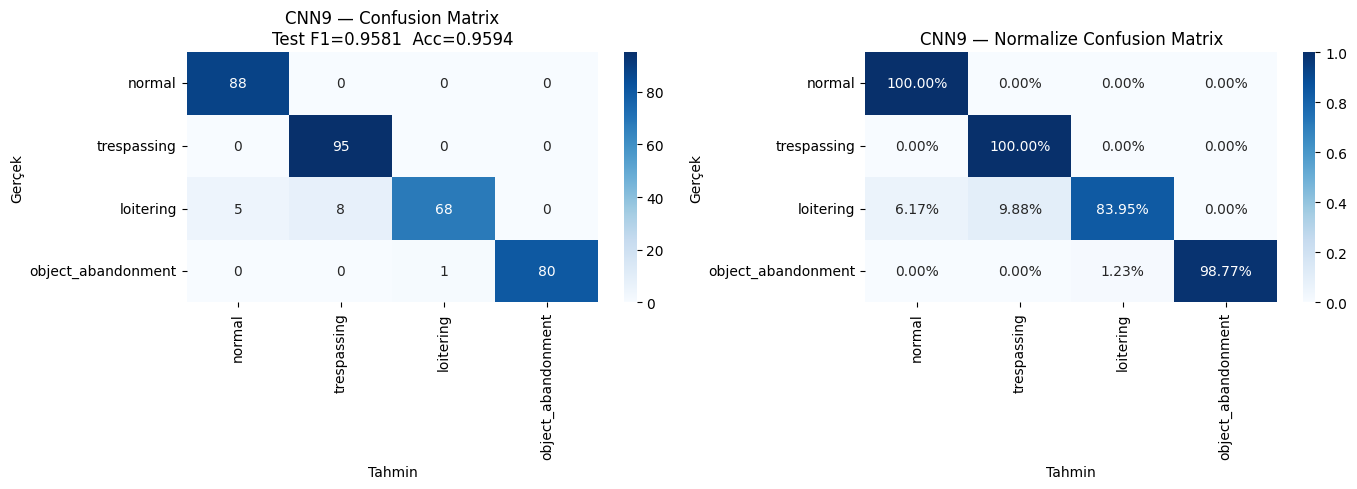


✓ Confusion matrix kaydedildi: /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model/final_test_confusion_matrix.png


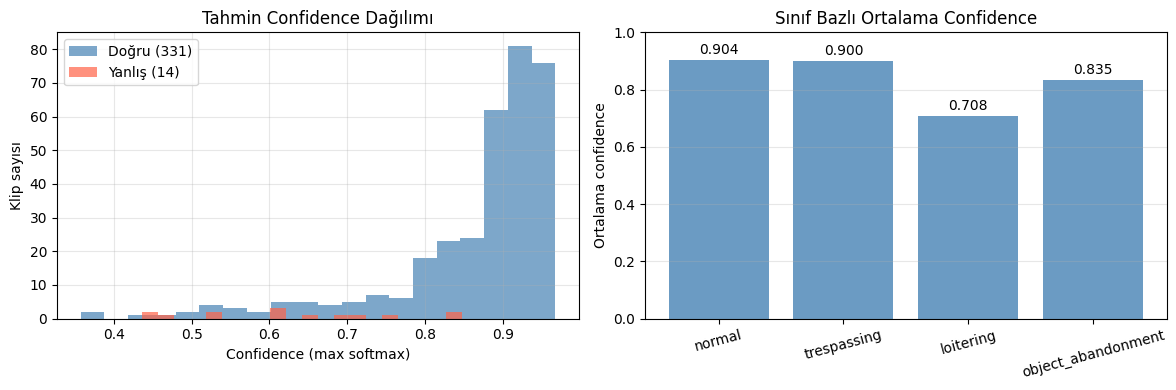

✓ Confidence grafikleri kaydedildi: /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model/final_test_confidence.png

  CNN9 FINAL ÖZET
  Test F1   : 0.9581
  Test Acc  : 0.9594
  Doğru/Top : 331 / 345


In [ ]:
import torchimport torch.nn as nnfrom torchvision.models.video import r3d_18, R3D_18_Weightsfrom torch.amp import autocastfrom torch.utils.data import Dataset, DataLoaderfrom sklearn.metrics import (classification_report, confusion_matrix,                              f1_score, accuracy_score)import numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom pathlib import Pathimport randomCLASSES   = ["normal", "trespassing", "loitering", "object_abandonment"]N_CLASSES = 4DEVICE    = torch.device("cuda")NPY_DIR    = Path("/content/training_final/npy_cache")MODEL_PATH = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model/best_model.pth")SAVE_DIR   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model")random.seed(42)np.random.seed(42)# ── Test Dataset ──────────────────────────────────────────────────────────────class TestDataset(Dataset):    def __init__(self):        self.samples = []        for cls in CLASSES:            cls_dir = NPY_DIR / "test" / cls            if not cls_dir.exists():                print(f"  [UYARI] Bulunamadı: {cls_dir}")                continue            files = sorted(cls_dir.rglob("*.npy"))            for npy in files:                self.samples.append((npy, CLASSES.index(cls)))        print(f"Test seti: {len(self.samples)} klip")        for cls in CLASSES:            n = sum(1 for _,l in self.samples if CLASSES[l]==cls)            print(f"  {cls:<25} {n:>4} klip")    def __len__(self): return len(self.samples)    def __getitem__(self, idx):        npy_path, label = self.samples[idx]        clip = np.load(str(npy_path))        return torch.from_numpy(clip).permute(1,0,2,3), labeltest_ds = TestDataset()test_loader = DataLoader(test_ds, batch_size=32, shuffle=False,                         num_workers=2, pin_memory=True)# ── Model ─────────────────────────────────────────────────────────────────────model = r3d_18(weights=None)model.fc = nn.Sequential(    nn.Dropout(0.5),    nn.Linear(model.fc.in_features, N_CLASSES))print(f"\nModel yükleniyor: {MODEL_PATH}")ckpt = torch.load(str(MODEL_PATH), map_location=DEVICE)model.load_state_dict(ckpt["model_state"])model = model.to(DEVICE)model.eval()print(f"  Best epoch : {ckpt['epoch']}")print(f"  Val F1     : {ckpt['val_f1']:.4f}")# ── Inference ─────────────────────────────────────────────────────────────────all_preds, all_labels, all_probs = [], [], []with torch.no_grad():    for clips, labels in test_loader:        clips = clips.to(DEVICE, non_blocking=True)        with autocast('cuda'):            logits = model(clips)        probs = torch.softmax(logits, dim=1)        preds = logits.argmax(1)        all_preds.extend(preds.cpu().numpy())        all_labels.extend(labels.numpy())        all_probs.extend(probs.cpu().numpy())all_preds  = np.array(all_preds)all_labels = np.array(all_labels)all_probs  = np.array(all_probs)acc = accuracy_score(all_labels, all_preds)f1  = f1_score(all_labels, all_preds, average='macro')print("\n" + "="*60)print("  CNN9 — FINAL TEST SONUÇLARI")print("="*60)print(f"\n  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")print(f"  Test F1 Macro : {f1:.4f}")print(f"\n  Toplam klip   : {len(all_labels)}")print(f"  Doğru         : {(all_preds==all_labels).sum()}")print(f"  Yanlış        : {(all_preds!=all_labels).sum()}")print("\nClassification Report:")print(classification_report(all_labels, all_preds,                             target_names=CLASSES, digits=4))print("Sınıf bazlı detay:")print(f"  {'Sınıf':<25} {'Doğru':>6} {'Toplam':>7} {'Acc':>7}")print("  " + "-"*48)for i, cls in enumerate(CLASSES):    mask    = all_labels == i    correct = (all_preds[mask] == all_labels[mask]).sum()    total   = mask.sum()    print(f"  {cls:<25} {correct:>6} {total:>7} {correct/total:>7.4f}")# ── Confusion Matrix ──────────────────────────────────────────────────────────cm = confusion_matrix(all_labels, all_preds)fig, axes = plt.subplots(1, 2, figsize=(14, 5))sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])axes[0].set_title(f"CNN9 — Confusion Matrix\nTest F1={f1:.4f}  Acc={acc:.4f}")axes[0].set_ylabel("Gerçek")axes[0].set_xlabel("Tahmin")cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])axes[1].set_title("CNN9 — Normalize Confusion Matrix")axes[1].set_ylabel("Gerçek")axes[1].set_xlabel("Tahmin")plt.tight_layout()out_path = SAVE_DIR / "final_test_confusion_matrix.png"plt.savefig(str(out_path), dpi=150, bbox_inches='tight')plt.show()print(f"\n✓ Confusion matrix kaydedildi: {out_path}")fig, axes = plt.subplots(1, 2, figsize=(12, 4))correct_mask   = all_preds == all_labelscorrect_confs  = all_probs[correct_mask].max(axis=1)incorrect_confs= all_probs[~correct_mask].max(axis=1)axes[0].hist(correct_confs,   bins=20, alpha=0.7,             color='steelblue', label=f'Doğru ({correct_mask.sum()})')axes[0].hist(incorrect_confs, bins=20, alpha=0.7,             color='tomato',    label=f'Yanlış ({(~correct_mask).sum()})')axes[0].set_xlabel("Confidence (max softmax)")axes[0].set_ylabel("Klip sayısı")axes[0].set_title("Tahmin Confidence Dağılımı")axes[0].legend()axes[0].grid(alpha=0.3)mean_conf = [all_probs[all_labels==i, i].mean() for i in range(N_CLASSES)]colors    = ['steelblue' if f1_score(all_labels==i, all_preds==i) > 0.9             else 'tomato' for i in range(N_CLASSES)]bars = axes[1].bar(CLASSES, mean_conf, color=colors, alpha=0.8)axes[1].set_ylim(0, 1)axes[1].set_ylabel("Ortalama confidence")axes[1].set_title("Sınıf Bazlı Ortalama Confidence")axes[1].tick_params(axis='x', rotation=15)for bar, val in zip(bars, mean_conf):    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)axes[1].grid(alpha=0.3, axis='y')plt.tight_layout()conf_path = SAVE_DIR / "final_test_confidence.png"plt.savefig(str(conf_path), dpi=150, bbox_inches='tight')plt.show()print(f"✓ Confidence grafikleri kaydedildi: {conf_path}")print("\n" + "="*60)print(f"  CNN9 FINAL ÖZET")print("="*60)print(f"  Test F1   : {f1:.4f}")print(f"  Test Acc  : {acc:.4f}")print(f"  Doğru/Top : {(all_preds==all_labels).sum()} / {len(all_labels)}")print("="*60)

In [ ]:
import torchimport torch.nn as nnfrom torchvision.models.video import r3d_18, R3D_18_Weightsfrom torch.amp import autocastimport numpy as npimport matplotlib.pyplot as pltimport cv2, random, timefrom pathlib import PathCLASSES    = ["normal", "trespassing", "loitering", "object_abandonment"]N_CLASSES  = 4DEVICE     = torch.device("cuda")LTD_DIR    = Path("/content/drive/MyDrive/archive/LTD Dataset/LTD Dataset/Video Clips")MODEL_PATH = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn9_model/best_model.pth")MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1,1)STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1,1)CLIP_FRAMES = 16random.seed(int(time.time()))COLORS = {    "normal":             "#4CAF50",    "trespassing":        "#F44336",    "loitering":          "#FF9800",    "object_abandonment": "#9C27B0"}def is_winter(day_name):    try: return 202101 <= int(day_name[:6]) <= 202103    except: return Falseall_days    = sorted([d for d in LTD_DIR.iterdir() if d.is_dir()])winter_days = [d for d in all_days if is_winter(d.name)]summer_days = [d for d in all_days if not is_winter(d.name)]print(f"Kış: {len(winter_days)} gün  |  Yaz: {len(summer_days)} gün")selected = ([(d,"KIŞ") for d in random.sample(winter_days, min(3,len(winter_days)))] +            [(d,"YAZ") for d in random.sample(summer_days, min(3,len(summer_days)))])def pick_video(day_dir):    videos = (list(day_dir.glob("*.mp4")) +              list(day_dir.glob("*.MP4")) +              list(day_dir.glob("*.avi")))    return random.choice(videos) if videos else Nonedef extract_clip(video_path, n_frames=16):    cap   = cv2.VideoCapture(str(video_path))    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))    if total < n_frames:        cap.release(); return None, None    start = max(0, total//2 - n_frames//2)    cap.set(cv2.CAP_PROP_POS_FRAMES, start)    frames_orig  = []    frames_model = []    for _ in range(n_frames):        ret, frame = cap.read()        if not ret: break        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)        frames_orig.append(rgb)        frames_model.append(cv2.resize(rgb, (112, 112)))    cap.release()    if len(frames_orig) < n_frames: return None, None    arr     = np.stack(frames_model).astype(np.float32) / 255.0    clip_np = arr.transpose(3, 0, 1, 2)    return clip_np, frames_origdef preprocess(clip_np):    t = torch.from_numpy(clip_np)    return ((t - MEAN) / STD).unsqueeze(0)# ── Model ─────────────────────────────────────────────────────────────────────model = r3d_18(weights=None)model.fc = nn.Sequential(nn.Dropout(0.5),                          nn.Linear(model.fc.in_features, N_CLASSES))ckpt = torch.load(str(MODEL_PATH), map_location=DEVICE)model.load_state_dict(ckpt["model_state"])model = model.to(DEVICE).eval()print(f"CNN9 yüklendi — val F1={ckpt['val_f1']:.4f}  epoch={ckpt['epoch']}\n")# ── Inference ─────────────────────────────────────────────────────────────────results = []for day_dir, season in selected:    vp = pick_video(day_dir)    if vp is None: print(f"[ATLA] {day_dir.name} — video yok"); continue    clip_np, frames_orig = extract_clip(vp)    if clip_np is None: print(f"[ATLA] {vp.name} — kare yok"); continue    with torch.no_grad():        with autocast('cuda'):            logits = model(preprocess(clip_np).to(DEVICE))        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]    pred_cls = CLASSES[probs.argmax()]    conf     = probs.max()    h, w     = frames_orig[0].shape[:2]    results.append(dict(season=season, day=day_dir.name, video=vp.name,                        pred=pred_cls, conf=conf, probs=probs,                        frames_orig=frames_orig, w=w, h=h))    sym = "❄️" if season=="KIŞ" else "☀️"    print(f"{'='*60}")    print(f"  {sym} {season}  Gün: {day_dir.name}  Video: {vp.name}")    print(f"  Boyut: {w}×{h}  |  Tahmin: {pred_cls.upper()}  conf={conf:.3f}")    for i, c in enumerate(CLASSES):        bar    = "█" * int(probs[i]*25)        marker = " ◄" if i==probs.argmax() else ""        print(f"    {c:<25} {probs[i]:.3f}  {bar}{marker}")    print()    color  = COLORS[pred_cls]    aspect = w / h    cell_w = 4.0    cell_h = cell_w / aspect    fig, axes = plt.subplots(2, 8, figsize=(cell_w*8, cell_h*2 + 1.2))    for f_idx, ax in enumerate(axes.flatten()):        ax.imshow(frames_orig[f_idx], interpolation='bilinear')        ax.axis('off')        ax.set_title(f"#{f_idx+1}", fontsize=9, pad=3)        for sp in ax.spines.values():            sp.set_visible(True)            sp.set_color(color)            sp.set_linewidth(2)    fig.suptitle(        f"{sym} {season}  |  {day_dir.name}  |  {vp.name}  [{w}×{h}]\n"        f"Tahmin: {pred_cls.upper()}   conf={conf:.3f}   "        f"N:{probs[0]:.2f}  T:{probs[1]:.2f}  L:{probs[2]:.2f}  O:{probs[3]:.2f}",        fontsize=11, fontweight='bold', color=color, y=1.01    )    plt.tight_layout()    plt.show()n = len(results)fig, axes = plt.subplots(2, n, figsize=(n*4, 8))if n == 1: axes = np.array([[axes[0]], [axes[1]]])for col, r in enumerate(results):    color = COLORS[r["pred"]]    sym   = "❄️" if r["season"]=="KIŞ" else "☀️"    ax_img = axes[0][col]    ax_img.imshow(r["frames_orig"][CLIP_FRAMES//2], interpolation='bilinear')    ax_img.axis('off')    ax_img.set_title(f"{sym} {r['season']}\n{r['day']}\n"                     f"→ {r['pred'].upper()}\nconf:{r['conf']:.3f}",                     fontsize=9, fontweight='bold', color=color, pad=4)    for sp in ax_img.spines.values():        sp.set_visible(True); sp.set_color(color); sp.set_linewidth(3)    ax_bar = axes[1][col]    bars = ax_bar.barh(CLASSES, r["probs"],                       color=[COLORS[c] for c in CLASSES], alpha=0.8)    ax_bar.set_xlim(0, 1)    ax_bar.set_xlabel("Confidence", fontsize=8)    ax_bar.tick_params(labelsize=8)    ax_bar.grid(axis='x', alpha=0.3)    for bar, prob in zip(bars, r["probs"]):        ax_bar.text(min(prob+0.02, 0.95), bar.get_y()+bar.get_height()/2,                    f'{prob:.3f}', va='center', fontsize=8)    pi = CLASSES.index(r["pred"])    bars[pi].set_alpha(1.0); bars[pi].set_linewidth(2); bars[pi].set_edgecolor('black')fig.suptitle("CNN9 — LTD Dataset Gerçek Dünya Testi  (3 kış ❄️ + 3 yaz ☀️)",             fontsize=12, fontweight='bold')plt.tight_layout()plt.show()print("\n" + "="*60)print("  ÖZET TABLO")print("="*60)print(f"  {'Msm':<4} {'Gün':<12} {'Boyut':<10} {'Tahmin':<22} {'Conf':>6}")print("  "+"-"*55)for r in results:    sym = "❄️" if r["season"]=="KIŞ" else "☀️"    print(f"  {sym}  {r['day']:<12} {r['w']}×{r['h']:<6} {r['pred']:<22} {r['conf']:>6.3f}")

Output hidden; open in https://colab.research.google.com to view.

  CNN9 Threshold Uygulaması  (eşik=0.72)

                              Orijinal   Threshold       Δ
  -------------------------------------------------------
  Macro F1                      0.9567      0.9721  +0.0154
  Accuracy                      0.9576      0.9727  +0.0152

── Sınıf Bazlı F1 ─────────────────────────────────────────
  Sınıf                      Orig F1    New F1       Δ   Orig Err    New Err
  -----------------------------------------------------------------
  normal                      0.9689    0.9689  +0.0000          0          0
  trespassing                 0.9574    0.9836  +0.0262          0          0 ✓
  loitering                   0.9067    0.9419  +0.0353         13          8 ✓
  object_abandonment          0.9938    0.9938  +0.0000          1          1

── Değişen Tahminler (5 klip) ──────────────────────────
  Gerçek                 Eski Tahmin            Yeni Tahmin             Tresp skoru
  -------------------------------------------------------

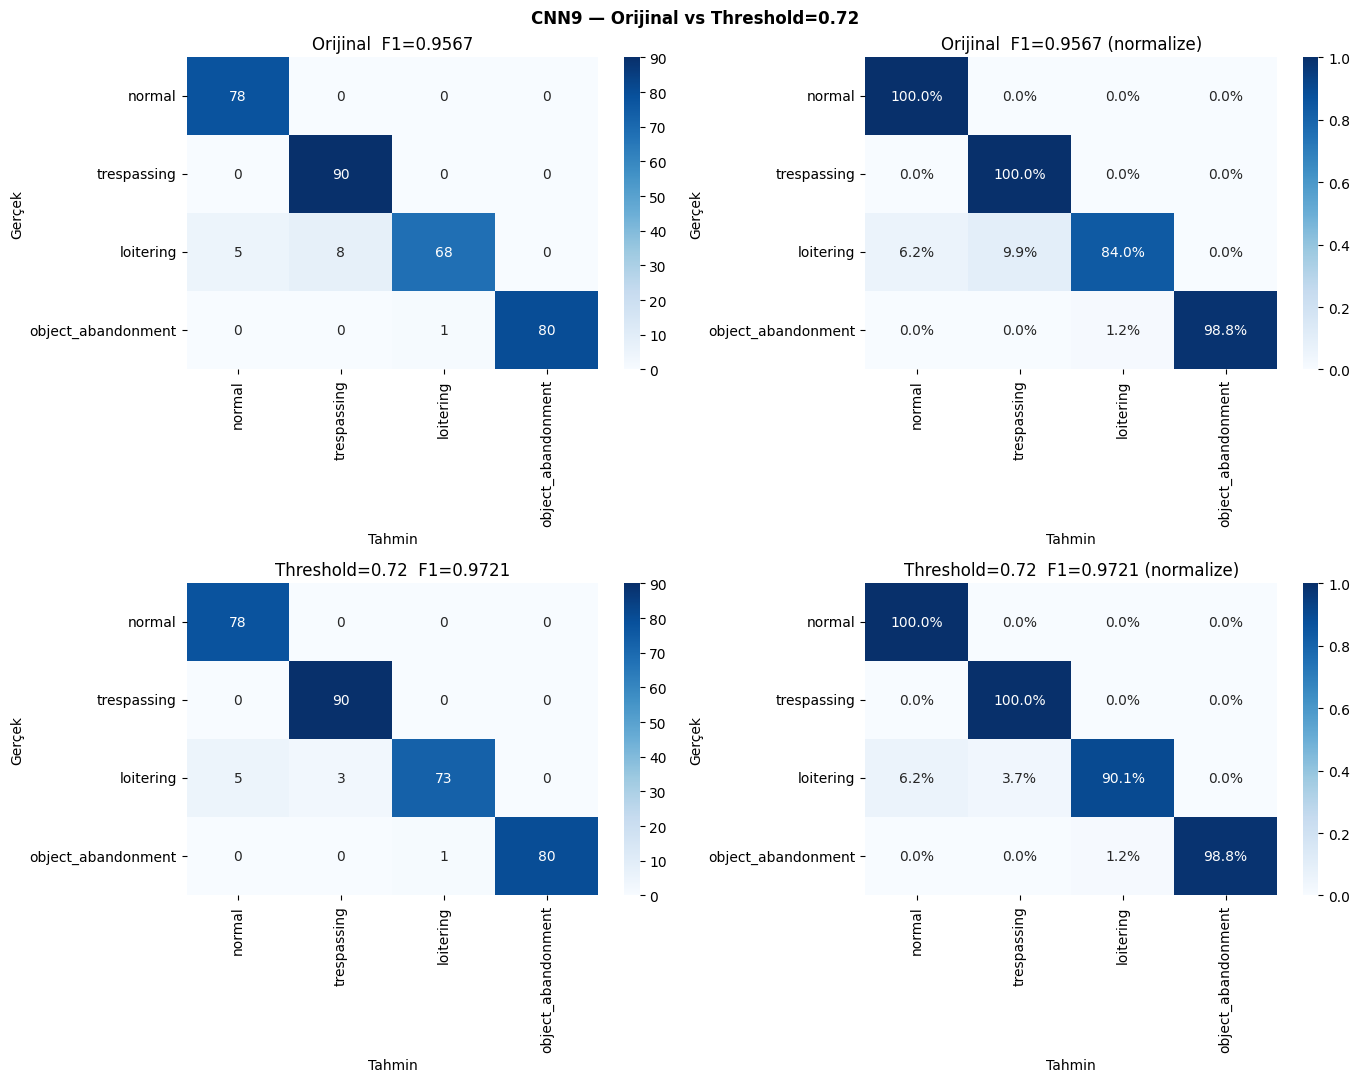


  ÖZET
  Threshold eşiği      : 0.72
  Değişen tahmin       : 5
  F1 değişimi          : 0.9567 → 0.9721  (+0.0154)
  Acc değişimi         : 0.9576 → 0.9727  (+0.0152)


In [ ]:
# Kural: trespassing skoru < 0.72 ise trespassing DEMEz,import numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import classification_report, confusion_matrix, f1_scoreCLASSES    = ["normal","trespassing","loitering","object_abandonment"]N_CLS      = 4T_IDX      = CLASSES.index("trespassing")THRESHOLD  = 0.72COLORS = {"normal":"#4CAF50","trespassing":"#F44336",          "loitering":"#FF9800","object_abandonment":"#9C27B0"}# ── Threshold uygula ──────────────────────────────────────────────────────────def apply_threshold(probs, threshold=0.72):    """    Her klip için:      - Trespassing skoru >= threshold → trespassing      - Trespassing skoru <  threshold → trespassing'i sıfırla,                                          kalan sınıflar arasından en yükseği al    """    new_preds = np.zeros(len(probs), dtype=int)    for i, p in enumerate(probs):        if p[T_IDX] >= threshold:            new_preds[i] = T_IDX        else:            p_masked = p.copy()            p_masked[T_IDX] = 0.0            new_preds[i] = p_masked.argmax()    return new_predsnew_preds = apply_threshold(probs, THRESHOLD)orig_f1 = f1_score(labels, preds,     average='macro')new_f1  = f1_score(labels, new_preds, average='macro')orig_acc = (preds     == labels).mean()new_acc  = (new_preds == labels).mean()print("="*62)print(f"  CNN9 Threshold Uygulaması  (eşik={THRESHOLD})")print("="*62)print(f"\n  {'':25} {'Orijinal':>10}  {'Threshold':>10}  {'Δ':>6}")print(f"  {'-'*55}")print(f"  {'Macro F1':<25} {orig_f1:>10.4f}  {new_f1:>10.4f}  "      f"{new_f1-orig_f1:>+6.4f}")print(f"  {'Accuracy':<25} {orig_acc:>10.4f}  {new_acc:>10.4f}  "      f"{new_acc-orig_acc:>+6.4f}")print(f"\n── Sınıf Bazlı F1 ─────────────────────────────────────────")print(f"  {'Sınıf':<25} {'Orig F1':>8}  {'New F1':>8}  {'Δ':>6}  "      f"{'Orig Err':>9}  {'New Err':>9}")print(f"  {'-'*65}")for i, cls in enumerate(CLASSES):    m = labels == i    orig_f1_cls = f1_score(labels==i, preds==i)    new_f1_cls  = f1_score(labels==i, new_preds==i)    orig_err = (preds[m]     != i).sum()    new_err  = (new_preds[m] != i).sum()    delta    = new_f1_cls - orig_f1_cls    marker   = " ✓" if delta > 0 else (" ✗" if delta < 0 else "")    print(f"  {cls:<25} {orig_f1_cls:>8.4f}  {new_f1_cls:>8.4f}  "          f"{delta:>+6.4f}  {orig_err:>9}  {new_err:>9}{marker}")changed = np.where(preds != new_preds)[0]print(f"\n── Değişen Tahminler ({len(changed)} klip) ──────────────────────────")print(f"  {'Gerçek':<22} {'Eski Tahmin':<22} {'Yeni Tahmin':<22} {'Tresp skoru':>12}")print(f"  {'-'*80}")for idx in sorted(changed, key=lambda i: probs[i][T_IDX], reverse=True):    g  = CLASSES[labels[idx]]    et = CLASSES[preds[idx]]    yt = CLASSES[new_preds[idx]]    ts = probs[idx][T_IDX]    correct = "✓ DÜZELDI" if labels[idx]==new_preds[idx] else "✗ hâlâ yanlış"    print(f"  {g:<22} {et:<22} {yt:<22} {ts:>12.3f}  {correct}")fig, axes = plt.subplots(2, 2, figsize=(14, 11))for row, (p, title) in enumerate([(preds,     f"Orijinal  F1={orig_f1:.4f}"),                                   (new_preds, f"Threshold={THRESHOLD}  F1={new_f1:.4f}")]):    cm      = confusion_matrix(labels, p)    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)    for col, (data, fmt) in enumerate([(cm,'d'), (cm_norm,'.1%')]):        ax = axes[row][col]        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)        ax.set_title(title + (" (normalize)" if col else ""))        ax.set_ylabel("Gerçek"); ax.set_xlabel("Tahmin")plt.suptitle(f"CNN9 — Orijinal vs Threshold={THRESHOLD}",             fontsize=12, fontweight='bold')plt.tight_layout()plt.show()print(f"\n{'='*62}")print(f"  ÖZET")print(f"{'='*62}")print(f"  Threshold eşiği      : {THRESHOLD}")print(f"  Değişen tahmin       : {len(changed)}")print(f"  F1 değişimi          : {orig_f1:.4f} → {new_f1:.4f}  ({new_f1-orig_f1:+.4f})")print(f"  Acc değişimi         : {orig_acc:.4f} → {new_acc:.4f}  ({new_acc-orig_acc:+.4f})")

 BURAYA KADAR SİNGLE-LABEL EĞİTİM YAPILDI ASAĞIDA DA MULTİLABEL EĞİTİM YAPILACAK 4 EK SINIF İLE TEMPORAL COMPOSİTE KULLANIP SOFTMAX  YERİNE SİGMOİD KULLANCAĞIZ


In [79]:
import cv2, numpy as np, matplotlib.pyplot as plt, randomfrom pathlib import PathLOCAL_BASE = Path("/content/training_final")ALL_CLASSES = [    "normal","trespassing","loitering","object_abandonment",    "loitering+trespassing","loitering+object_abandonment",    "trespassing+object_abandonment",    "loitering+trespassing+object_abandonment",]random.seed(42)for split in ["train","test"]:    print(f"\n{'='*50}  {split.upper()}")    for cls in ALL_CLASSES:        cls_dir = LOCAL_BASE/split/cls        if not cls_dir.exists():            print(f"  [YOK] {split}/{cls}"); continue        clips = [f.parent for f in cls_dir.rglob("frame_001.jpg")]        if not clips:            print(f"  [BOŞ] {split}/{cls}"); continue        samples = random.sample(clips, min(9, len(clips)))        n = len(clips)        fig, axes = plt.subplots(3, 3, figsize=(15, 12))        axes = axes.flatten()        for i in range(9):            ax = axes[i]            if i < len(samples):                jpgs = sorted(samples[i].glob("*.jpg"))                img  = cv2.imread(str(jpgs[min(7, len(jpgs)-1)]))                rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)                ax.imshow(rgb); ax.axis('off')                ax.set_title(samples[i].name[:20], fontsize=7, pad=2)            else:                ax.axis('off')        fig.suptitle(            f"{split.upper()} / {cls}  ({n} klip)",            fontsize=12, fontweight='bold', y=1.01        )        plt.tight_layout()        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [78]:
import cv2, numpy as np, shutil, random, timefrom pathlib import Pathfrom tqdm import tqdmLOCAL_BASE = Path("/content/training_final")DRIVE_BASE = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")random.seed(42)cls_local = LOCAL_BASE/"train"/"loitering+trespassing+object_abandonment"cls_drive = DRIVE_BASE/"train"/"loitering+trespassing+object_abandonment"def aug_gaussian(frames):    std=random.uniform(0.01,0.03)    return [(np.clip(f.astype(np.float32)/255+np.random.normal(0,std,f.shape).astype(np.float32),0,1)*255).astype(np.uint8) for f in frames]def aug_bright(frames):    return [np.clip(f.astype(np.float32)*random.uniform(0.8,1.2),0,255).astype(np.uint8) for f in frames]def aug_contrast(frames):    a=random.uniform(0.85,1.15)    return [np.clip((f.astype(np.float32)-f.mean())*a+f.mean(),0,255).astype(np.uint8) for f in frames]def aug_gamma(frames):    t=np.array([(i/255)**random.uniform(0.8,1.3)*255 for i in range(256)]).astype(np.uint8)    return [cv2.LUT(f,t) for f in frames]def aug_blur(frames): return [cv2.GaussianBlur(f,(3,3),0) for f in frames]def aug_rev(frames): return list(reversed(frames))def aug_sp(frames):    out=[]    for f in frames:        o=f.copy(); n=int(0.005*f.size)        r,c=np.random.randint(0,f.shape[0],n),np.random.randint(0,f.shape[1],n); o[r,c]=255        r,c=np.random.randint(0,f.shape[0],n),np.random.randint(0,f.shape[1],n); o[r,c]=0        out.append(o)    return outAUGS=[aug_gaussian,aug_bright,aug_contrast,aug_gamma,aug_blur,aug_rev,aug_sp]def apply_aug(frames):    for fn in random.sample(AUGS,random.randint(1,2)): frames=fn(frames)    return framesdef read_frames(d):    out=[]    for jp in sorted(d.glob("*.jpg"))[:16]:        img=cv2.imread(str(jp))        if img is not None: out.append(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))    return outdef write_clip(frames,dst):    dst.mkdir(parents=True,exist_ok=True)    for i,f in enumerate(frames):        cv2.imwrite(str(dst/f"frame_{i+1:03d}.jpg"),cv2.cvtColor(f,cv2.COLOR_RGB2BGR))def copy_to_drive(l,d):    d.mkdir(parents=True,exist_ok=True)    for jp in l.glob("*.jpg"):        dp=d/jp.name        if not dp.exists(): shutil.copy2(str(jp),str(dp))# ── ADIM 1: Augmentation → 250+ ──────────────────────────────────────────────print("ADIM 1: Augmentation...")all_f1  = sorted(cls_local.rglob("frame_001.jpg"))orig    = [f.parent for f in all_f1]current = len(all_f1)needed  = max(0, 250-current)print(f"  Mevcut:{current}  Üretilecek:{needed}")existing={f.parent.name for f in all_f1}random.shuffle(orig)gen=idx=cyc=0pbar=tqdm(total=needed,desc="loi+tresp+obj")while gen<needed:    if cyc>len(orig)*500: break    src=orig[cyc%len(orig)]; cyc+=1    frames=read_frames(src)    if len(frames)<8: continue    aug_f=apply_aug(frames)    name=f"augml_{idx:06d}_{src.name}"    if name in existing: idx+=1; continue    day=src.parent.name    l_dst=cls_local/day/name    d_dst=cls_drive/day/name    if not l_dst.exists():        write_clip(aug_f,l_dst)        copy_to_drive(l_dst,d_dst)        existing.add(name)    gen+=1; idx+=1; pbar.update(1)pbar.close()# ── ADIM 2: Drive'daki eski klipler → sil, yenilerini yaz ────────────────────print("\nADIM 2: Drive güncelleniyor...")if cls_drive.exists():    shutil.rmtree(str(cls_drive))print("  Drive'a yazılıyor...")from concurrent.futures import ThreadPoolExecutordef copy_jpg(args):    s,d=args; d.parent.mkdir(parents=True,exist_ok=True)    if not d.exists(): shutil.copy2(str(s),str(d))tasks=[(f, cls_drive/f.relative_to(cls_local))       for f in cls_local.rglob("*.jpg")]t0=time.time()with ThreadPoolExecutor(max_workers=64) as ex:    list(tqdm(ex.map(copy_jpg,tasks),total=len(tasks),desc="Drive"))print(f"  ✓ {time.time()-t0:.0f}sn")print("\nFinal Özet — training_final\n"+"="*55)ALL = [    "normal","trespassing","loitering","object_abandonment",    "loitering+trespassing","loitering+object_abandonment",    "trespassing+object_abandonment",    "loitering+trespassing+object_abandonment",]for split in ["train","test"]:    print(f"\n  {split}:")    total=0    for cls in ALL:        d=LOCAL_BASE/split/cls        n=len(list(d.rglob("frame_001.jpg"))) if d.exists() else 0        total+=n        ok="✓" if (n>=250 and split=="train") or (n>=80 and split=="test") else "⚠"        print(f"  {ok}  {cls:<45} {n:>4}")    print(f"       {'TOPLAM':<45} {total:>4}")

ADIM 1: Augmentation...
  Mevcut:250  Üretilecek:0


loi+tresp+obj: 0it [00:00, ?it/s]


ADIM 2: Drive güncelleniyor...


  Drive'a yazılıyor...


Drive: 100%|██████████| 4000/4000 [00:30<00:00, 130.17it/s]


  ✓ 31sn

Final Özet — training_final

  train:
  ✓  normal                                         273
  ✓  trespassing                                    250
  ✓  loitering                                      273
  ✓  object_abandonment                             261
  ✓  loitering+trespassing                          260
  ✓  loitering+object_abandonment                   305
  ✓  trespassing+object_abandonment                 250
  ✓  loitering+trespassing+object_abandonment       250
       TOPLAM                                        2122

  test:
  ✓  normal                                          88
  ✓  trespassing                                     85
  ✓  loitering                                       81
  ✓  object_abandonment                              81
  ✓  loitering+trespassing                           80
  ✓  loitering+object_abandonment                    80
  ✓  trespassing+object_abandonment                  80
  ✓  loitering+trespassing+object_abandonment

In [80]:
# ═══════════════════════════════════════════════════════════# ═══════════════════════════════════════════════════════════import cv2, numpy as np, random, timefrom pathlib import Pathfrom concurrent.futures import ThreadPoolExecutorfrom tqdm import tqdmLOCAL_BASE = Path("/content/training_final")NPY_BASE   = Path("/content/npy_final")WORKERS    = 8MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)STD  = np.array([0.229,0.224,0.225], dtype=np.float32)ALL_CLASSES = [    "normal","trespassing","loitering","object_abandonment",    "loitering+trespassing","loitering+object_abandonment",    "trespassing+object_abandonment",    "loitering+trespassing+object_abandonment",]def clip_to_npy(args):    clip_dir, out_path = args    if out_path.exists(): return "skip"    jpgs = sorted(clip_dir.glob("*.jpg"))[:16]    if len(jpgs) < 8: return "fail"    frames = []    for jp in jpgs:        img = cv2.imread(str(jp))        if img is None: return "fail"        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)        frames.append(cv2.resize(rgb, (112,112)))    if len(frames) < 16:        frames += [frames[-1]] * (16-len(frames))    arr = np.stack(frames).astype(np.float32)/255.0    arr = (arr - MEAN) / STD    out_path.parent.mkdir(parents=True, exist_ok=True)    np.save(str(out_path), arr.transpose(3,0,1,2).astype(np.float32))    return "ok"print("NPY cache oluşturuluyor...\n"+"="*55)total_ok = total_skip = total_fail = 0t0 = time.time()for split in ["train","test"]:    for cls in ALL_CLASSES:        cls_dir = LOCAL_BASE/split/cls        if not cls_dir.exists(): continue        tasks = []        for f1 in sorted(cls_dir.rglob("frame_001.jpg")):            cd  = f1.parent            out = NPY_BASE/split/cls/(cd.name+".npy")            tasks.append((cd, out))        n_exist = sum(1 for _,o in tasks if o.exists())        if n_exist == len(tasks):            print(f"  ✓ {split}/{cls}: {n_exist} NPY var")            total_skip += n_exist; continue        stats={"ok":0,"skip":0,"fail":0}        with ThreadPoolExecutor(max_workers=WORKERS) as ex:            for r in tqdm(ex.map(clip_to_npy,tasks),                          total=len(tasks), desc=f"{split}/{cls[:20]}"):                stats[r]+=1        total_ok+=stats["ok"]; total_skip+=stats["skip"]; total_fail+=stats["fail"]        print(f"  {split}/{cls}: ok:{stats['ok']} skip:{stats['skip']} fail:{stats['fail']}")print(f"\n✓ Toplam: ok:{total_ok} skip:{total_skip} fail:{total_fail} ({time.time()-t0:.0f}sn)")

NPY cache oluşturuluyor...


train/normal: 100%|██████████| 273/273 [00:01<00:00, 196.04it/s]


  train/normal: ok:189 skip:84 fail:0


train/trespassing: 100%|██████████| 250/250 [00:03<00:00, 80.82it/s]


  train/trespassing: ok:250 skip:0 fail:0


...

  test/loitering+object_abandonment: ok:80 skip:0 fail:0


test/trespassing+object_a: 100%|██████████| 80/80 [00:00<00:00, 117.95it/s]


  test/trespassing+object_abandonment: ok:80 skip:0 fail:0


test/loitering+trespassin: 100%|██████████| 85/85 [00:00<00:00, 124.21it/s]

  test/loitering+trespassing+object_abandonment: ok:85 skip:0 fail:0

✓ Toplam: ok:2642 skip:135 fail:5 (24sn)


[train] 1985 klip  orig:925  comp:1060
[test] 649 klip  orig:325  comp:324

── Val Split ───────────────────────────────────────
  Sınıf                                          Train    Val
  ----------------------------------------------------------
  normal                                           146     36
  trespassing                                      200     50
  loitering                                        203     50
  object_abandonment                               192     48
  loitering+trespassing                            204     51
  loitering+object_abandonment                     244     61
  trespassing+object_abandonment                   200     50
  loitering+trespassing+object_abandonment         200     50

Train:1589  Val:396  Test:649

  CNN Multi-label Final — 50 epoch  |  8 sınıf
Epoch  1/50 [FC] tr:0.5949 val:0.5085 f1:0.540 lr:1.0e-03 9sn
  ✓ best F1=0.5401
Epoch  2/50 [FC] tr:0.5022 val:0.4520 f1:0.611 lr:1.0e-03 7sn
  ✓ best F1=0.6109
Epoch  3/50

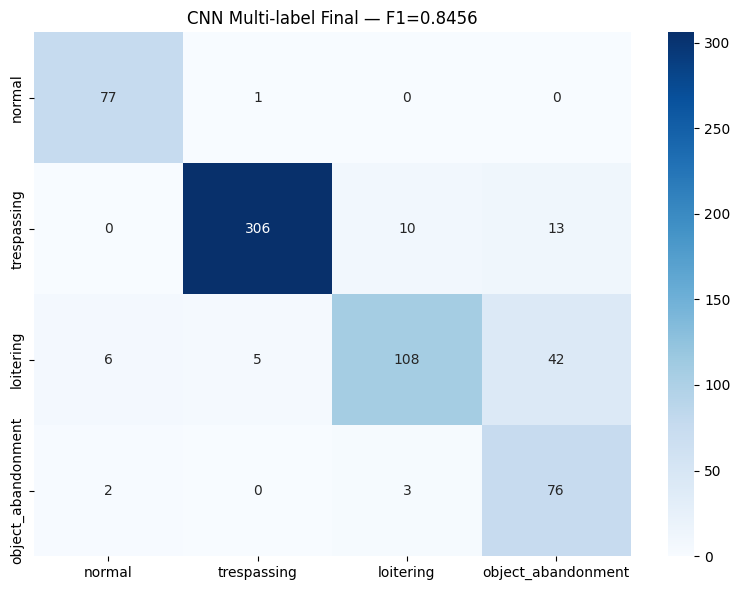

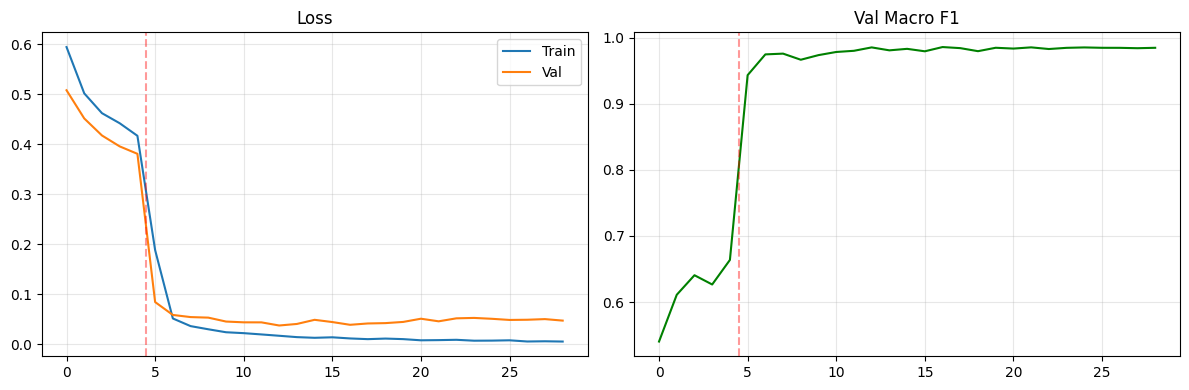


✓ Kaydedildi: /content/cnn_multilabel_final  /  /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn_multilabel_final_model


In [81]:
# ═══════════════════════════════════════════════════════════# ═══════════════════════════════════════════════════════════import torch, torch.nn as nn, torch.optim as optimimport numpy as np, random, shutil, timefrom torchvision.models.video import r3d_18, R3D_18_Weightsfrom torch.amp import GradScaler, autocastfrom torch.utils.data import Dataset, DataLoader, Subsetfrom sklearn.metrics import f1_score, classification_report, confusion_matrixfrom pathlib import Pathfrom collections import defaultdictimport matplotlib.pyplot as pltimport seaborn as sns# ── Sabitler ─────────────────────────────────────────────────────────────────ORIG_CLASSES = ["normal","trespassing","loitering","object_abandonment"]NEW_CLASSES  = [    "loitering+trespassing","loitering+object_abandonment",    "trespassing+object_abandonment",    "loitering+trespassing+object_abandonment",]ALL_CLASSES = ORIG_CLASSES + NEW_CLASSESN_ORIG      = len(ORIG_CLASSES)# Composite binary etiketler (4 boyutlu)COMP_LABELS = {    "loitering+trespassing":                    [0,1,1,0],    "loitering+object_abandonment":             [0,0,1,1],    "trespassing+object_abandonment":           [0,1,0,1],    "loitering+trespassing+object_abandonment": [0,1,1,1],}NPY_BASE   = Path("/content/npy_final")SAVE_LOCAL = Path("/content/cnn_multilabel_final")SAVE_DRIVE = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final/cnn_multilabel_final_model")SAVE_LOCAL.mkdir(exist_ok=True)SAVE_DRIVE.mkdir(parents=True, exist_ok=True)DEVICE       = torch.device("cuda")EPOCHS_FC    = 5EPOCHS_FT    = 45EPOCHS_TOTAL = EPOCHS_FC + EPOCHS_FTPATIENCE     = 12BATCH        = 32LR_FC        = 1e-3LR_FT        = 1e-4WD           = 5e-4DROPOUT      = 0.5VAL_RATIO    = 0.20THRESHOLD    = 0.5torch.backends.cudnn.benchmark = Truerandom.seed(42); np.random.seed(42)# ── Dataset ───────────────────────────────────────────────────────────────────class MultiLabelDS(Dataset):    def __init__(self, split, augment=False):        self.samples = []        self.augment = augment        for ci, cls in enumerate(ORIG_CLASSES):            label = [0.0]*N_ORIG; label[ci] = 1.0            d = NPY_BASE/split/cls            if not d.exists(): continue            for npy in sorted(d.glob("*.npy")):                self.samples.append((npy, label[:]))        for cls in NEW_CLASSES:            label = [float(x) for x in COMP_LABELS[cls]]            d = NPY_BASE/split/cls            if not d.exists(): continue            for npy in sorted(d.glob("*.npy")):                self.samples.append((npy, label[:]))        random.shuffle(self.samples)        n_orig = sum(1 for _,l in self.samples if sum(l)==1)        n_comp = sum(1 for _,l in self.samples if sum(l)>1)        print(f"[{split}] {len(self.samples)} klip  orig:{n_orig}  comp:{n_comp}")    def __len__(self): return len(self.samples)    def __getitem__(self, idx):        npy_path, label = self.samples[idx]        clip = np.load(str(npy_path))   # (3,16,112,112)        if self.augment and random.random() > 0.5:            # Hafif brightness jitter — flip YOK            fac  = random.uniform(0.85, 1.15)            clip = np.clip(clip * fac, clip.min(), clip.max()).astype(np.float32)        return (torch.from_numpy(clip),                torch.tensor(label, dtype=torch.float32))train_ds = MultiLabelDS("train", augment=True)test_ds  = MultiLabelDS("test",  augment=False)# ── Val split ─────────────────────────────────────────────────────────────────def val_split(samples, ratio=VAL_RATIO):    train_idx, val_idx = [], []    print("\n── Val Split ───────────────────────────────────────")    print(f"  {'Sınıf':<45} {'Train':>6} {'Val':>6}")    print("  "+"-"*58)    for ci, cls in enumerate(ORIG_CLASSES):        idxs = [i for i,(p,l) in enumerate(samples)                if l[ci]==1.0 and sum(l)==1.0]        random.shuffle(idxs)        nv = int(len(idxs)*ratio)        val_idx.extend(idxs[:nv]); train_idx.extend(idxs[nv:])        print(f"  {cls:<45} {len(idxs)-nv:>6} {nv:>6}")    for cls in NEW_CLASSES:        label = [float(x) for x in COMP_LABELS[cls]]        idxs  = [i for i,(p,l) in enumerate(samples) if l==label]        random.shuffle(idxs)        nv = int(len(idxs)*ratio)        val_idx.extend(idxs[:nv]); train_idx.extend(idxs[nv:])        print(f"  {cls:<45} {len(idxs)-nv:>6} {nv:>6}")    return train_idx, val_idxtrain_idx, val_idx = val_split(train_ds.samples)train_sub = Subset(train_ds, train_idx)val_sub   = Subset(train_ds, val_idx)print(f"\nTrain:{len(train_sub)}  Val:{len(val_sub)}  Test:{len(test_ds)}")kw = dict(num_workers=2, pin_memory=True,          persistent_workers=True, prefetch_factor=2)train_loader = DataLoader(train_sub, BATCH, shuffle=True,  **kw)val_loader   = DataLoader(val_sub,   BATCH, shuffle=False, **kw)test_loader  = DataLoader(test_ds,   BATCH, shuffle=False, **kw)# ── Model ─────────────────────────────────────────────────────────────────────model = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)model.fc = nn.Sequential(nn.Dropout(DROPOUT),                          nn.Linear(model.fc.in_features, N_ORIG))model     = model.to(DEVICE)criterion = nn.BCEWithLogitsLoss()scaler    = GradScaler('cuda')def freeze(m):    for n,p in m.named_parameters():        if "fc" not in n: p.requires_grad=Falsedef unfreeze(m):    for p in m.parameters(): p.requires_grad=Truefreeze(model)optimizer = optim.AdamW(    filter(lambda p:p.requires_grad, model.parameters()),    lr=LR_FC, weight_decay=WD)# ── Train/Eval ────────────────────────────────────────────────────────────────def train_epoch(loader):    model.train(); ls=n=0    for clips,lbs in loader:        clips=clips.to(DEVICE,non_blocking=True)        lbs=lbs.to(DEVICE,non_blocking=True)        optimizer.zero_grad(set_to_none=True)        with autocast('cuda'):            loss=criterion(model(clips),lbs)        scaler.scale(loss).backward()        scaler.step(optimizer); scaler.update()        ls+=loss.item()*lbs.size(0); n+=lbs.size(0)    return ls/ndef eval_epoch(loader):    model.eval(); ls=n=0    all_probs,all_lbl=[],[]    with torch.no_grad():        for clips,lbs in loader:            clips=clips.to(DEVICE,non_blocking=True)            lbs=lbs.to(DEVICE,non_blocking=True)            with autocast('cuda'):                logits=model(clips); loss=criterion(logits,lbs)            all_probs.extend(torch.sigmoid(logits).cpu().numpy())            all_lbl.extend(lbs.cpu().numpy())            ls+=loss.item()*lbs.size(0); n+=lbs.size(0)    probs=np.array(all_probs); lbls=np.array(all_lbl)    preds=(probs>THRESHOLD).astype(float)    f1=f1_score(lbls,preds,average='macro',zero_division=0)    return ls/n, f1, probs, lblsbest_f1=patience_cnt=0history=defaultdict(list)scheduler=Noneprint("\n"+"="*60)print(f"  CNN Multi-label Final — {EPOCHS_TOTAL} epoch  |  8 sınıf")print("="*60)for epoch in range(1, EPOCHS_TOTAL+1):    t0 = time.time()    if epoch == EPOCHS_FC+1:        print("\n→ Backbone açıldı")        unfreeze(model)        optimizer = optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=WD)        scheduler = optim.lr_scheduler.ReduceLROnPlateau(            optimizer,'min',factor=0.5,patience=5,min_lr=1e-6)    tr_loss = train_epoch(train_loader)    vl_loss, vl_f1,_,_ = eval_epoch(val_loader)    if scheduler: scheduler.step(vl_loss)    history["tr"].append(tr_loss)    history["vl"].append(vl_loss)    history["f1"].append(vl_f1)    phase = "FC" if epoch<=EPOCHS_FC else "FT"    lr    = optimizer.param_groups[0]['lr']    print(f"Epoch {epoch:>2}/{EPOCHS_TOTAL} [{phase}] "          f"tr:{tr_loss:.4f} val:{vl_loss:.4f} f1:{vl_f1:.3f} "          f"lr:{lr:.1e} {time.time()-t0:.0f}sn")    if vl_f1 > best_f1:        best_f1=vl_f1; patience_cnt=0        ckpt={"epoch":epoch,"model_state":model.state_dict(),              "val_f1":vl_f1,"history":dict(history)}        torch.save(ckpt, str(SAVE_LOCAL/"best_model.pth"))        shutil.copy2(str(SAVE_LOCAL/"best_model.pth"),                     str(SAVE_DRIVE/"best_model.pth"))        print(f"  ✓ best F1={best_f1:.4f}")    else:        patience_cnt+=1        if patience_cnt>=PATIENCE and epoch>EPOCHS_FC:            print("  Early stopping"); break# ── Final test ────────────────────────────────────────────────────────────────print("\n"+"="*60+"  FINAL TEST")ckpt = torch.load(str(SAVE_LOCAL/"best_model.pth"))model.load_state_dict(ckpt["model_state"])_,_,all_probs,all_lbl = eval_epoch(test_loader)pred_idx = all_probs.argmax(axis=1)true_idx = all_lbl.argmax(axis=1)f1_final = f1_score(true_idx, pred_idx, average='macro')print(f"\nBest epoch:{ckpt['epoch']}  Test F1:{f1_final:.4f}")print(f"\nKarşılaştırma:")print(f"  CNN9+threshold=0.72  : 0.9721")print(f"  Multi-label final    : {f1_final:.4f}  ← şu an")print(f"\n{classification_report(true_idx,pred_idx,target_names=ORIG_CLASSES,digits=3)}")cm = confusion_matrix(true_idx, pred_idx)fig,ax=plt.subplots(figsize=(8,6))sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',            xticklabels=ORIG_CLASSES,yticklabels=ORIG_CLASSES,ax=ax)ax.set_title(f"CNN Multi-label Final — F1={f1_final:.4f}")plt.tight_layout()for d in [SAVE_LOCAL,SAVE_DRIVE]:    plt.savefig(str(d/"confusion_matrix.png"),dpi=150)plt.show()fig,axes=plt.subplots(1,2,figsize=(12,4))axes[0].plot(history["tr"],label="Train")axes[0].plot(history["vl"],label="Val")axes[0].axvline(EPOCHS_FC-.5,color='red',ls='--',alpha=0.4)axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)axes[1].plot(history["f1"],color='green')axes[1].axvline(EPOCHS_FC-.5,color='red',ls='--',alpha=0.4)axes[1].set_title("Val Macro F1"); axes[1].grid(alpha=0.3)plt.tight_layout()for d in [SAVE_LOCAL,SAVE_DRIVE]:    plt.savefig(str(d/"training_curves.png"),dpi=150)plt.show()print(f"\n✓ Kaydedildi: {SAVE_LOCAL}  /  {SAVE_DRIVE}")

In [83]:
class OrigOnlyDS(Dataset):    def __init__(self):        self.samples = []        for ci, cls in enumerate(ORIG_CLASSES):            label = [0.0]*N_ORIG; label[ci] = 1.0            d = NPY_BASE/"test"/cls            if not d.exists(): continue            for npy in sorted(d.glob("*.npy")):                self.samples.append((npy, label[:]))        print(f"[test_orig] {len(self.samples)} klip")    def __len__(self): return len(self.samples)    def __getitem__(self,idx):        p,l = self.samples[idx]        return torch.from_numpy(np.load(str(p))), torch.tensor(l,dtype=torch.float32)test_orig_ds     = OrigOnlyDS()test_orig_loader = DataLoader(test_orig_ds, 32, shuffle=False,                               num_workers=2, pin_memory=True)ckpt = torch.load("/content/cnn_multilabel_final/best_model.pth")model.load_state_dict(ckpt["model_state"])_,_,all_probs,all_lbl = eval_epoch(test_orig_loader)pred_idx = all_probs.argmax(axis=1)true_idx = all_lbl.argmax(axis=1)f1_final = f1_score(true_idx, pred_idx, average='macro')print(f"Test F1 (sadece 4 orijinal sınıf): {f1_final:.4f}")print(f"\nKarşılaştırma:")print(f"  CNN9+threshold=0.72  : 0.9721")print(f"  Multi-label final    : {f1_final:.4f}")print(f"\n{classification_report(true_idx,pred_idx,target_names=ORIG_CLASSES,digits=3)}")

[test_orig] 325 klip
Test F1 (sadece 4 orijinal sınıf): 0.9657

Karşılaştırma:
  CNN9+threshold=0.72  : 0.9721
  Multi-label final    : 0.9657

                    precision    recall  f1-score   support

            normal      0.939     0.987     0.963        78
       trespassing      0.988     1.000     0.994        85
         loitering      0.962     0.938     0.950        81
object_abandonment      0.974     0.938     0.956        81

          accuracy                          0.966       325
         macro avg      0.966     0.966     0.966       325
      weighted avg      0.966     0.966     0.966       325



[full_test] 649 klip


/tmp/ipykernel_5939/59262771.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


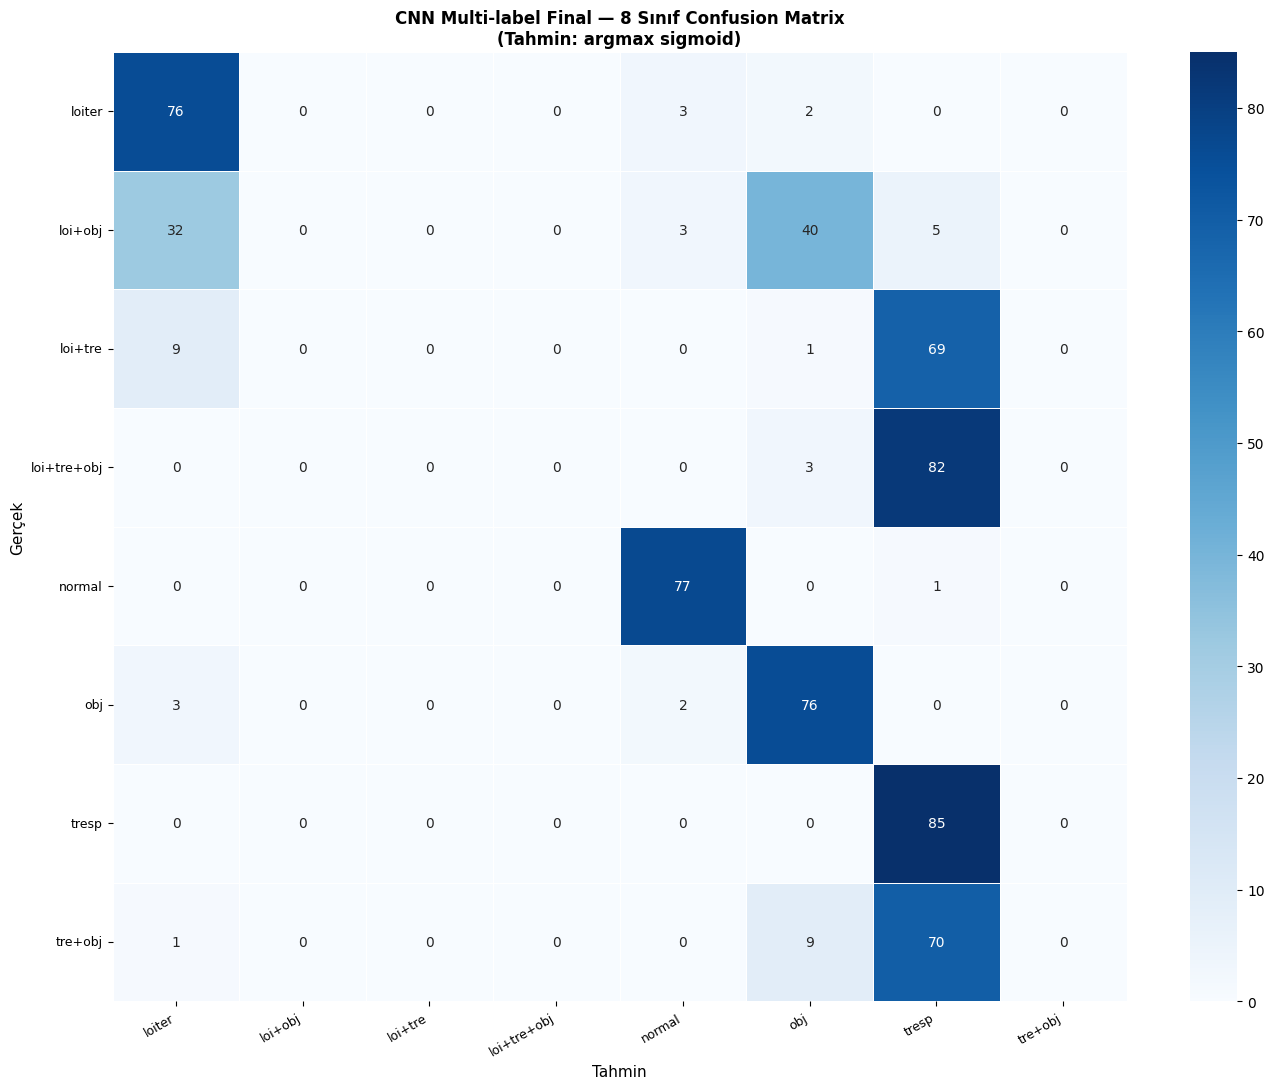


Gerçek Sınıf                         Toplam   Doğru     Acc
-------------------------------------------------------
  loitering                               0       0    0.0%
  loitering+object_abandonment            0       0    0.0%
  loitering+trespassing                   0       0    0.0%
  loitering+trespassing+object_abandonment       0       0    0.0%
  normal                                 78      77   98.7%
  object_abandonment                      0       0    0.0%
  trespassing                             0       0    0.0%
  trespassing+object_abandonment          0       0    0.0%


In [84]:
import numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import confusion_matrix, f1_scorefrom torch.utils.data import Dataset, DataLoaderimport torchclass FullTestDS(Dataset):    def __init__(self):        self.samples = []        for ci, cls in enumerate(ALL_CLASSES):            if cls in ORIG_CLASSES:                label = [0.0]*N_ORIG; label[ORIG_CLASSES.index(cls)] = 1.0            else:                label = [float(x) for x in COMP_LABELS[cls]]            d = NPY_BASE/"test"/cls            if not d.exists(): continue            for npy in sorted(d.glob("*.npy")):                self.samples.append((npy, label[:], cls))        print(f"[full_test] {len(self.samples)} klip")    def __len__(self): return len(self.samples)    def __getitem__(self,idx):        p,l,cls = self.samples[idx]        return torch.from_numpy(np.load(str(p))), torch.tensor(l,dtype=torch.float32), clsfull_ds     = FullTestDS()full_loader = DataLoader(full_ds, 32, shuffle=False, num_workers=2, pin_memory=True)# Inferencemodel.eval()all_probs, all_true_cls, all_pred_cls = [], [], []with torch.no_grad():    for clips, lbs, cls_names in full_loader:        with torch.cuda.amp.autocast():            logits = model(clips.to(DEVICE))        probs = torch.sigmoid(logits).cpu().numpy()        for i, p in enumerate(probs):            pred_idx  = p.argmax()            pred_label = [1.0 if j==pred_idx else 0.0 for j in range(N_ORIG)]            true_label = lbs[i].numpy().tolist()            true_cls = cls_names[i]            if sum(true_label) > 1:                pred_cls = ORIG_CLASSES[pred_idx]            else:                pred_cls = ORIG_CLASSES[pred_idx]            all_true_cls.append(true_cls)            all_pred_cls.append(pred_cls)            all_probs.append(p)unique_true = sorted(set(all_true_cls))unique_pred = sorted(set(all_pred_cls))all_labels  = sorted(set(unique_true + unique_pred))SHORT = {    "normal":                              "normal",    "trespassing":                         "tresp",    "loitering":                           "loiter",    "object_abandonment":                  "obj",    "loitering+trespassing":               "loi+tre",    "loitering+object_abandonment":        "loi+obj",    "trespassing+object_abandonment":      "tre+obj",    "loitering+trespassing+object_abandonment": "loi+tre+obj",}true_short = [SHORT.get(c,c) for c in all_true_cls]pred_short = [SHORT.get(c,c) for c in all_pred_cls]labels_short = [SHORT.get(c,c) for c in all_labels]cm = confusion_matrix(true_short, pred_short, labels=labels_short)fig, ax = plt.subplots(figsize=(14,11))sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',            xticklabels=labels_short, yticklabels=labels_short, ax=ax,            linewidths=0.5)ax.set_xlabel("Tahmin", fontsize=11)ax.set_ylabel("Gerçek", fontsize=11)ax.set_title("CNN Multi-label Final — 8 Sınıf Confusion Matrix\n(Tahmin: argmax sigmoid)",             fontsize=12, fontweight='bold')plt.xticks(rotation=30, ha='right', fontsize=9)plt.yticks(rotation=0, fontsize=9)plt.tight_layout()plt.show()print(f"\n{'Gerçek Sınıf':<35} {'Toplam':>7} {'Doğru':>7} {'Acc':>7}")print("-"*55)for cls in all_labels:    mask  = [t==cls for t in true_short]    total = sum(mask)    correct = sum(1 for t,p in zip(true_short,pred_short) if t==cls and p==cls)    acc = correct/total if total>0 else 0    print(f"  {cls:<33} {total:>7} {correct:>7} {acc:>7.1%}")

Test: 649 klip


/tmp/ipykernel_5939/3632703266.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


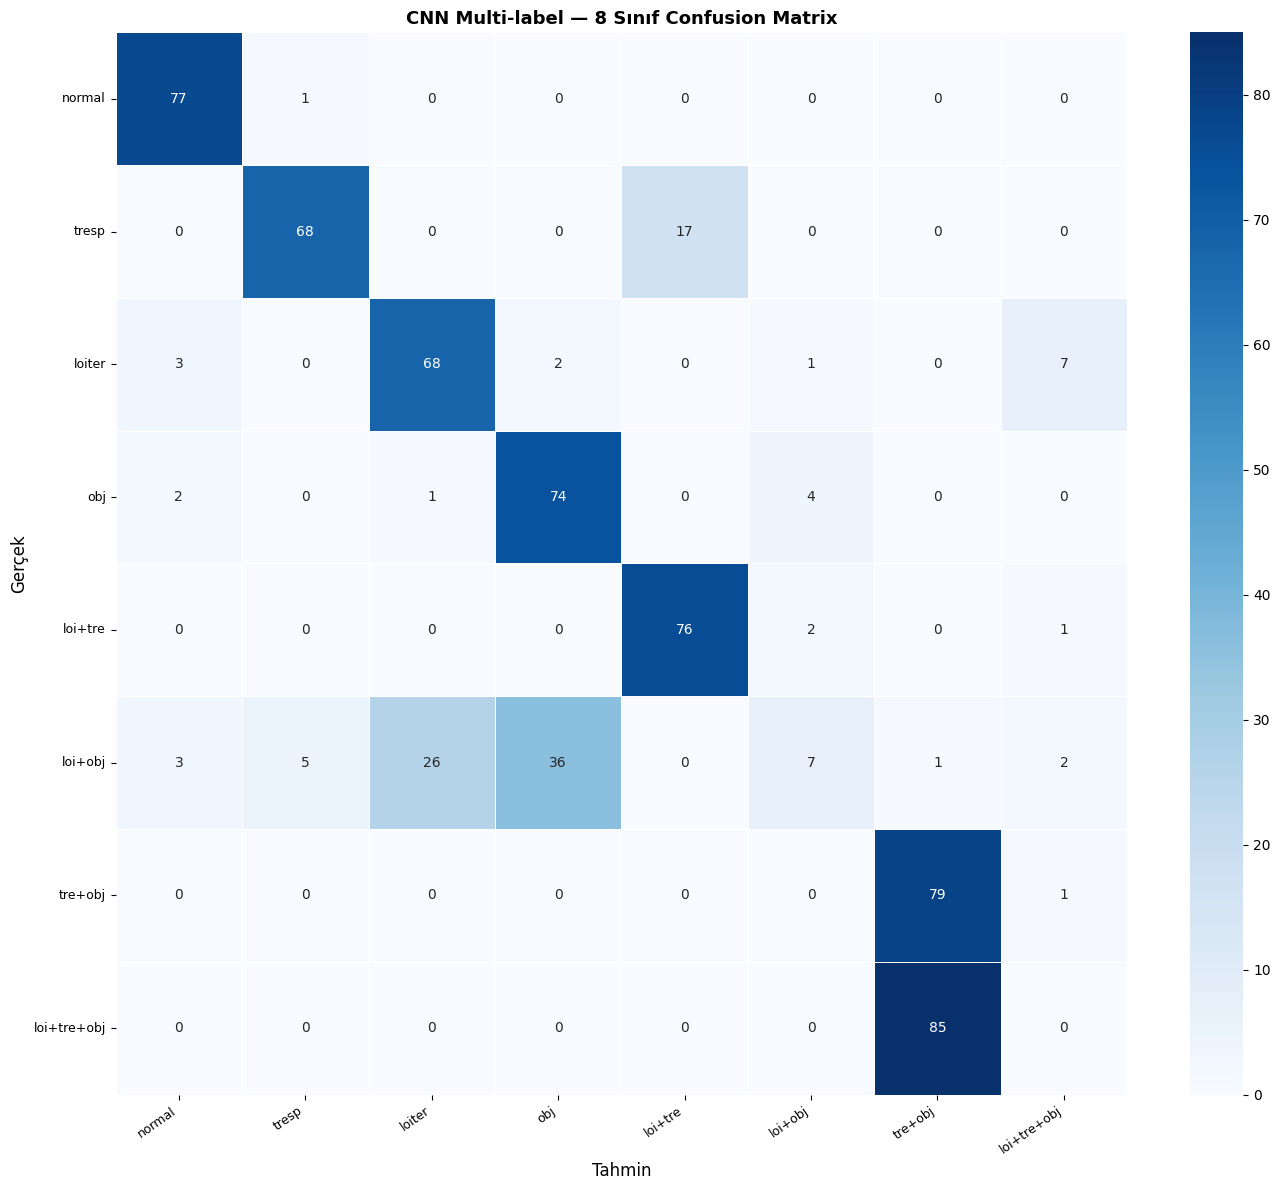


Sınıf                                Toplam   Doğru     Acc
-------------------------------------------------------
  ✓ normal                                 78      77   98.7%
  ✓ trespassing                            85      68   80.0%
  ✓ loitering                              81      68   84.0%
  ✓ object_abandonment                     81      74   91.4%
  ✓ loitering+trespassing                  79      76   96.2%
  ⚠ loitering+object_abandonment           80       7    8.8%
  ✓ trespassing+object_abandonment         80      79   98.8%
  ⚠ loitering+trespassing+object_abandonment      85       0    0.0%

Örnek frameler basılıyor...


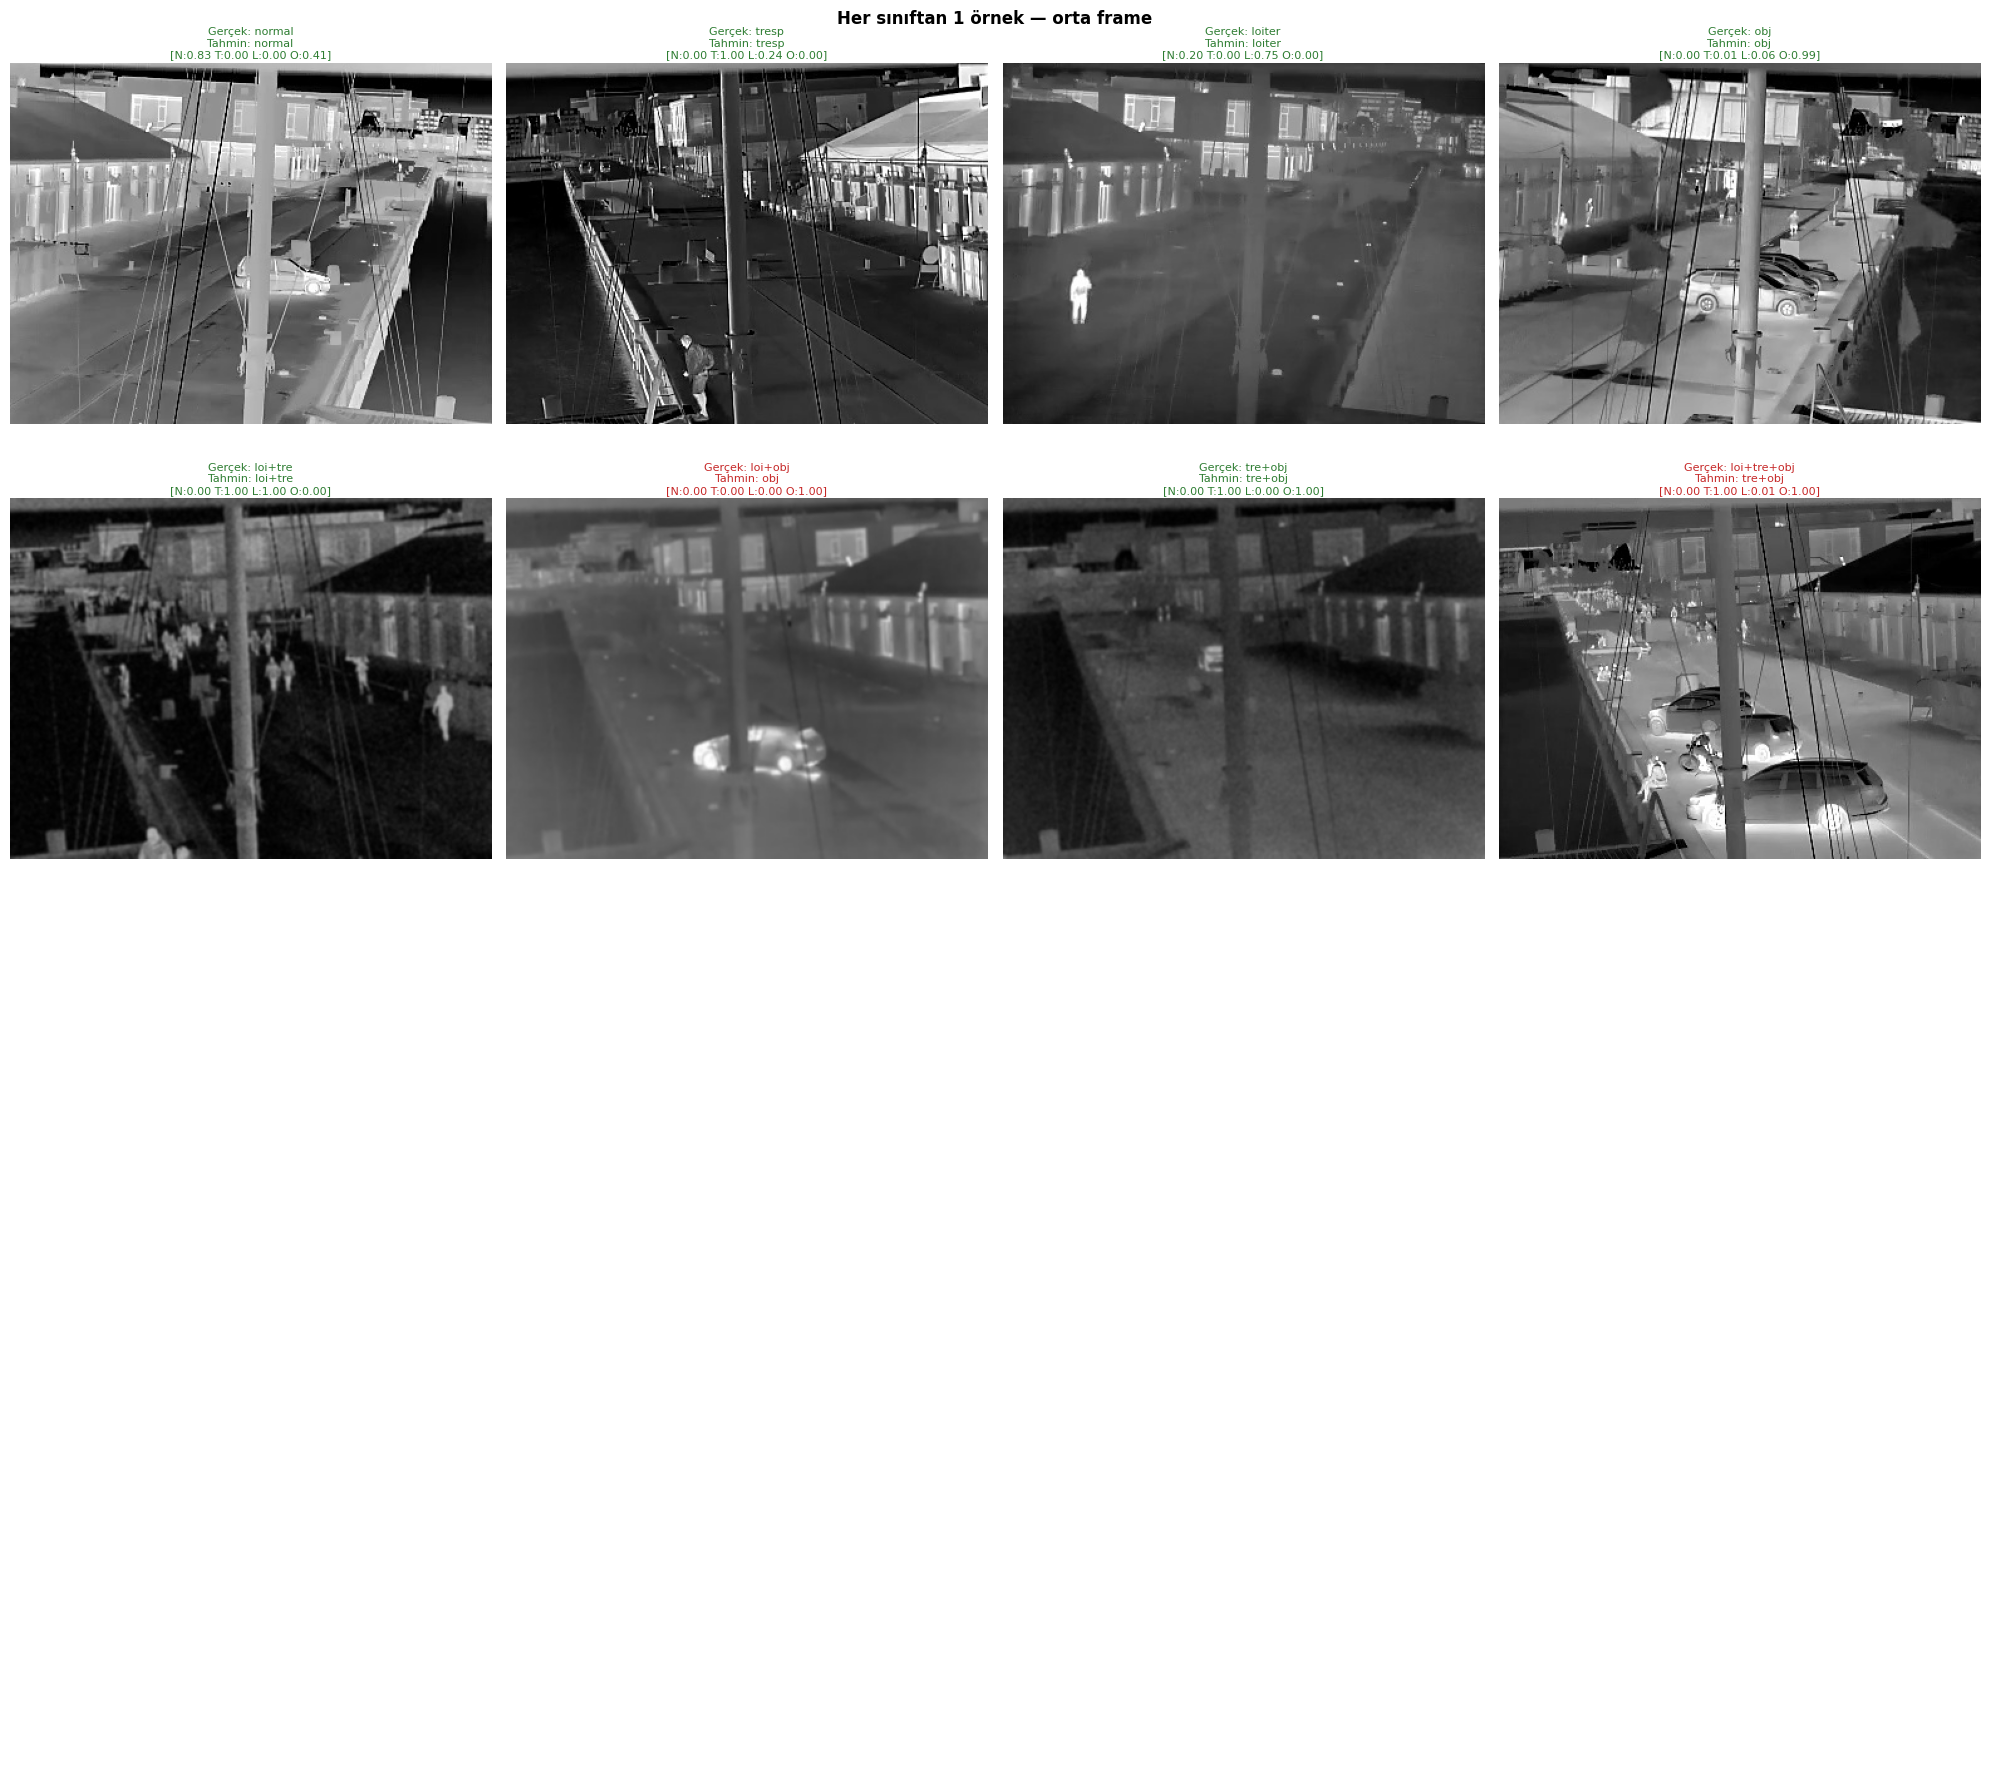

In [85]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, cv2, torch, randomfrom torch.utils.data import Dataset, DataLoaderfrom pathlib import PathNPY_BASE   = Path("/content/npy_final")LOCAL_BASE = Path("/content/training_final")DEVICE     = torch.device("cuda")ALL_CLASSES = [    "normal","trespassing","loitering","object_abandonment",    "loitering+trespassing","loitering+object_abandonment",    "trespassing+object_abandonment",    "loitering+trespassing+object_abandonment",]ORIG_CLASSES = ["normal","trespassing","loitering","object_abandonment"]N_ORIG = 4COMP_LABELS = {    "loitering+trespassing":                    [0,1,1,0],    "loitering+object_abandonment":             [0,0,1,1],    "trespassing+object_abandonment":           [0,1,0,1],    "loitering+trespassing+object_abandonment": [0,1,1,1],}CLASS_VECTORS = {}for cls in ORIG_CLASSES:    v = [0.0]*N_ORIG; v[ORIG_CLASSES.index(cls)]=1.0    CLASS_VECTORS[cls] = vfor cls, v in COMP_LABELS.items():    CLASS_VECTORS[cls] = [float(x) for x in v]SHORT = {    "normal":"normal","trespassing":"tresp","loitering":"loiter",    "object_abandonment":"obj","loitering+trespassing":"loi+tre",    "loitering+object_abandonment":"loi+obj",    "trespassing+object_abandonment":"tre+obj",    "loitering+trespassing+object_abandonment":"loi+tre+obj",}# Datasetclass Full8DS(Dataset):    def __init__(self):        self.samples=[]        for cls in ALL_CLASSES:            d=NPY_BASE/"test"/cls            if not d.exists(): continue            for npy in sorted(d.glob("*.npy")):                self.samples.append((npy,cls))    def __len__(self): return len(self.samples)    def __getitem__(self,i):        p,cls=self.samples[i]        return torch.from_numpy(np.load(str(p))), clsds     = Full8DS()loader = DataLoader(ds,32,shuffle=False,num_workers=2,pin_memory=True)print(f"Test: {len(ds)} klip")# Inferencemodel.eval()results = []  # (true_cls, pred_cls, probs, npy_path)with torch.no_grad():    for clips, cls_names in loader:        with torch.cuda.amp.autocast():            logits = model(clips.to(DEVICE))        probs_batch = torch.sigmoid(logits).cpu().numpy()        for i, p in enumerate(probs_batch):            best_cls, best_dist = None, 999            pred_bin = (p > 0.5).astype(float)            for cls, vec in CLASS_VECTORS.items():                dist = np.sum(np.abs(np.array(vec) - pred_bin))                if dist < best_dist:                    best_dist=dist; best_cls=cls            # Tie-break: argmax            if best_dist > 0:                best_cls = ALL_CLASSES[p.argmax()] if p.argmax()<4 else best_cls            results.append((cls_names[i], best_cls, p, ds.samples[len(results)][0]))true_list = [SHORT[r[0]] for r in results]pred_list = [SHORT[r[1]] for r in results]labels_s  = [SHORT[c] for c in ALL_CLASSES]# ── Confusion matrix ──────────────────────────────────────────────────────────from sklearn.metrics import confusion_matrixcm = confusion_matrix(true_list, pred_list, labels=labels_s)fig,ax=plt.subplots(figsize=(14,12))sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',            xticklabels=labels_s,yticklabels=labels_s,            ax=ax,linewidths=0.5,annot_kws={"size":10})ax.set_xlabel("Tahmin",fontsize=12); ax.set_ylabel("Gerçek",fontsize=12)ax.set_title("CNN Multi-label — 8 Sınıf Confusion Matrix",fontsize=13,fontweight='bold')plt.xticks(rotation=35,ha='right',fontsize=9)plt.yticks(rotation=0,fontsize=9)plt.tight_layout(); plt.show()print(f"\n{'Sınıf':<35} {'Toplam':>7} {'Doğru':>7} {'Acc':>7}")print("-"*55)for cls in ALL_CLASSES:    s = SHORT[cls]    total   = sum(1 for t,_ in zip(true_list,pred_list) if t==s)    correct = sum(1 for t,p in zip(true_list,pred_list) if t==s and p==s)    acc = correct/total if total>0 else 0    ok  = "✓" if acc>=0.8 else "⚠"    print(f"  {ok} {cls:<33} {total:>7} {correct:>7} {acc:>7.1%}")print("\nÖrnek frameler basılıyor...")fig,axes=plt.subplots(4,4,figsize=(20,18))axes=axes.flatten()for i,cls in enumerate(ALL_CLASSES):    sample = next((r for r in results if r[0]==cls), None)    if sample is None:        axes[i*2].axis('off'); axes[i*2+1].axis('off'); continue    true_cls, pred_cls, probs, npy_path = sample    clip_name = npy_path.stem    day       = npy_path.parent.parent.name    # Local'de bul    clip_dir  = None    for split_dir in [LOCAL_BASE/"test"/cls]:        for day_d in split_dir.iterdir():            cand = day_d/clip_name            if cand.exists(): clip_dir=cand; break        if clip_dir: break    ax = axes[i]    if clip_dir:        jpgs = sorted(clip_dir.glob("*.jpg"))        mid  = jpgs[min(7,len(jpgs)-1)]        img  = cv2.cvtColor(cv2.imread(str(mid)),cv2.COLOR_BGR2RGB)        ax.imshow(img)    ax.axis('off')    prob_str = " ".join([f"{ORIG_CLASSES[j][0].upper()}:{probs[j]:.2f}" for j in range(4)])    color = "#2E7D32" if true_cls==pred_cls else "#C62828"    ax.set_title(        f"Gerçek: {SHORT[true_cls]}\nTahmin: {SHORT[pred_cls]}\n[{prob_str}]",        fontsize=8,color=color,pad=3)for j in range(len(ALL_CLASSES),16): axes[j].axis('off')fig.suptitle("Her sınıftan 1 örnek — orta frame",fontsize=12,fontweight='bold')plt.tight_layout(); plt.show()

In [86]:
import cv2, numpy as np, matplotlib.pyplot as pltfrom pathlib import PathLOCAL_BASE = Path("/content/training_final")NPY_BASE   = Path("/content/npy_final")ORIG_CLASSES = ["normal","trespassing","loitering","object_abandonment"]COLORS = {"normal":"#4CAF50","trespassing":"#F44336",          "loitering":"#FF9800","object_abandonment":"#9C27B0"}print("2+ sigmoid > 0.5 olan klipler:\n")multi_examples = []for true_cls, pred_cls, probs, npy_path in results:    active = [(ORIG_CLASSES[i], probs[i]) for i in range(4) if probs[i] > 0.5]    if len(active) >= 2:        multi_examples.append((true_cls, pred_cls, probs, npy_path, active))print(f"Toplam {len(multi_examples)} klipte 2+ sınıf aktif\n")for tc, pc, p, path, active in multi_examples[:5]:    print(f"  Gerçek:{tc}  |  Aktif: {active}")show = multi_examples[:12]  # ilk 12fig, axes = plt.subplots(len(show), 2, figsize=(12, len(show)*3.5))if len(show)==1: axes=[axes]for row, (true_cls, pred_cls, probs, npy_path, active) in enumerate(show):    # Frame bul    clip_name = npy_path.stem    frame_img = None    for split in ["test","train"]:        for cls in [true_cls]+list(COMP_LABELS.keys()):            cls_dir = LOCAL_BASE/split/cls if (LOCAL_BASE/split/cls).exists() else None            if not cls_dir: continue            for day_d in cls_dir.iterdir():                cand = day_d/clip_name                if cand.exists():                    jpgs = sorted(cand.glob("*.jpg"))                    if jpgs:                        img = cv2.imread(str(jpgs[min(7,len(jpgs)-1)]))                        if img is not None:                            frame_img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)                    break            if frame_img is not None: break        if frame_img is not None: break    # Sol: frame    ax_img = axes[row][0]    if frame_img is not None:        ax_img.imshow(frame_img)    ax_img.axis('off')    active_str = " + ".join([f"{c[:3].upper()}:{v:.2f}" for c,v in active])    ax_img.set_title(f"Gerçek: {true_cls}\nAktif: {active_str}",                     fontsize=8, color='darkblue', pad=3)    ax_bar = axes[row][1]    bar_colors = [COLORS[c] for c in ORIG_CLASSES]    bars = ax_bar.bar(range(4), probs, color=bar_colors, alpha=0.8, width=0.6)    ax_bar.axhline(0.5, color='red', linestyle='--', alpha=0.6, linewidth=1.5)    ax_bar.set_xticks(range(4))    ax_bar.set_xticklabels([c[:6] for c in ORIG_CLASSES], fontsize=8)    ax_bar.set_ylim(0,1); ax_bar.grid(axis='y',alpha=0.3)    ax_bar.set_title(f"Sigmoid çıkışları\n(kırmızı = 0.5 eşik)", fontsize=8)    for i, p in enumerate(probs):        if p > 0.5:            bars[i].set_edgecolor('black')            bars[i].set_linewidth(2.5)fig.suptitle("Multi-label Örnekler — 2+ Sınıf 0.5 Üstü",             fontsize=12, fontweight='bold')plt.tight_layout()plt.show()print(f"\n✓ {len(multi_examples)} klipte model 2+ sınıf tespit etti")

Output hidden; open in https://colab.research.google.com to view.